<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 11 — Black-box Optimisation, Functions 1–8

- success: all except F6
- fail: F6

## W11 Approach

| # | Surrogate Model (W11) | Acquisition | Key Hyperparameters | Hyperparameter Tuning Notes |
|---|---|---|---|---|
| **F1** | GP, Matérn ν=2.5 | EI (ξ=0.5), signed-score transform | Fixed length-scale (ls≈0.05, from 3-point distance estimate), `OFFSET=300` for log transform | Length-scale fixed from historical "source-1" points rather than fitted; assertion added to guard against `OFFSET` being too small for the data's dynamic range |
| **F2** | GP, Matérn (anisotropic/ARD) | UCB (κ=1.0) with min-distance exclusion | `min_dist=0.1` excludes candidates near prior points | Length-scale bounds set from RF partial-dependence output ranges; initial length scales set short for important dims, long for unimportant ones |
| **F3** | ExtraTrees (200 trees) on degree-2 polynomial features, `log(-Y)` target | LCB (κ=0.3), min-distance filter | `max_features='sqrt'`, `min_samples_leaf=2`, `min_distance=0.001` | LOO-CV comparison across none/sqrt/log transforms picked log as best fit |
| **F4** | GP, Matérn ν=2.5 | EI (ξ=0.01), switched from UCB | Kernel: `ConstantKernel × Matern(length_scale=0.4, fixed)`, `alpha=1e-4`, `n_restarts_optimizer=20` | Candidate pool built from local perturbations (σ=0.08) around W7/W8 queries + global random, rather than a single scheme |
| **F5** | SVR pre-filter → GP (`log1p` outputs) | EI (ξ=0.005) | SVR: `C=100, gamma='scale', epsilon=0.01`; GP: `length_scale=0.2`, `n_restarts_optimizer=25` | Out-of-bounds historical points explicitly excluded from training; candidate generation redesigned with hard `[0,1]` assertion after repeated boundary violations |
| **F6** | GP, ARD Matérn + White (SVR kept for SHAP only) | UCB (κ=2.5), two-stage LHS (global + local refinement) | GP: `length_scale=ones(5)` bounds `(1e-2,1e2)`, `noise_level=1e-3`; refinement radius=0.05, `top_k=50` | SVR (`C=50, gamma=0.1, epsilon=0.001`) diagnosed as overfitting via train-vs-LOO MAE gap (large ratio) and demoted to interpretability-only role |
| **F7** | GP, Matérn + DotProduct on `sqrt(Y)` | EI (ξ=0.01), multi-start L-BFGS-B in adaptive trust region | Kernel `length_scale=[0.3]×6`, bounds `(0.05,5.0)`; trust region from top-K=8 points + 15% margin | W10-style two-stage RF filtering (100k → 10k → 1k) audited and found to fail (predicted Y below record); replaced with continuous trust-region optimization as the W11 fix |
| **F8** | MC-Dropout MLP (hidden=48, dropout=0.25) | UCB, adaptive κ = `κ_base(1.7) × calibration ratio` | `lr=1e-3`, 1500 epochs, weighted loss (5×/10× for high-scoring points), 50k LHS candidate pool | Dropout increased 0.2 → 0.25 for better calibration; capacity increased 24 → 48 hidden units; sample weighting added after top-k LOO calibration showed high-scoring points were under-predicted |

## Query Pattern Evolution (W2 → W11)

| # | Clusters / Recurring Regions | Strategy Strengths / Weaknesses | Hierarchical Clustering Parallel | Plot Insights |
|---|---|---|---|---|
| **F1** | Early scouting → GP/UCB churn with 2 negative failures (W4, W7) → tight convergence W8–10 → W11 reintroduces EI | Dominant basin (0.72–0.75, 0.71–0.75); off-cluster points fail | GP+EI strong once log/signed transform matched dynamic range; high-κ UCB pushed into negative outputs | Agglomerative — queries pull into a shrinking neighborhood around best points | Contour heatmaps confirm new query isn't redundant with existing cluster |
| **F2** | Out-of-bounds W2 → RF/GP model swaps → x2 drifts toward 0 boundary → W10 pure exploitation (risky) → W11 restores uncertainty | x1 ≈ 0.68–0.71, x2 → 0 (boundary-seeking) | RF+Thompson/UCB effective but plateaued; posterior-mean-only exploitation lacked escape capacity | Distance-exclusion filter (`min_dist=0.1`) acts like a linkage threshold | PDP plots set length-scale bounds; 1D sensitivity sweep checks GP over-interpolation |
| **F3** | Exploration mix → ExtraTrees churn → identical queries W5 = W6 (stagnation) → stable convergence | Cluster near (0.32–0.40, 0.30–0.38, 0.45–0.53); W7 excursion fails | ExtraTrees + polynomial features solid, but ensemble stopped learning from new points | Candidates repeatedly merge into same basin, like cluster convergence | SHAP/PDP-style feature reasoning guides polynomial interaction choices |
| **F4** | Failing W2 → SVM-gated GP → identical W4 = W5 queries → W10 pure exploitation | Cluster near (0.37–0.43, 0.40–0.45, 0.34–0.49, 0.36–0.49) | GP selected via LOO R² outperformed RF; pure exploitation risky without uncertainty term | Human-guided narrowing (W9) resembles manual branch selection | Diagnostic response-surface plots directly steer next-week search direction |
| **F5** | Out-of-bounds W2 → SVR-filter + GP churn → progressive boundary creep W6–10 → best result found outside domain | No stable interior cluster; drifts toward x2–x4 ≈ 1 boundary | SVR pre-filtering aided high-dim search but never resolved boundary-escaping behavior | Weak parallel — behaves more like an unmerged/outlier point than a forming cluster | Log-space GP plots reveal skewed, boundary-driven surface |
| **F6** | ARD GP → RF/Thompson → hybrid GP+RF → two-stage LHS refinement | Not detailed with explicit coordinates; SHAP-informed narrowing by W9 | SHAP explainability directly shaped later search direction; hybrid blending balanced surrogate weaknesses | Global → local two-stage LHS mirrors top-down divisive splitting | SHAP feature-importance plots justify which recipe variables to refine |
| **F7** | RF+SHAP exploitation → two-stage RF filtering → subspace narrowing → progressively tighter candidate funnels (100k → 10k → 1k) | Dominant subspace (e.g., HP1 region) isolated by RF filtering | Two-stage RF → GP pipeline effectively reduced dimensionality; risk of overly narrowing before global search is validated | Strongest divisive-clustering parallel — top-down candidate splitting at each stage | Filtering-stage plots show shrinking candidate pool concentrating around dominant subspace |
| **F8** | MLP/MC-Dropout churn W4–10 → increasing calibration (adaptive κ) → stable dimension-pinning pattern | Structural subspace cluster: dims 1, 2, 3, 6 → 0; dims 4/5 stay high | MC-Dropout UCB well-suited to corner-seeking structure; early fixed-dropout needed tuning | Dendrogram-like — informative dimensions refined, uninformative ones "cut" early | SHAP-informed candidate generation shows which dimensions drive output, guiding pinning |

In [1]:
# -----------------------------------------------------------------------------
# Imports
# -----------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
import shap
import torch
import torch.nn as nn
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats import norm, rankdata
from scipy.stats.qmc import LatinHypercube
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    DotProduct,
    Matern,
    WhiteKernel,
)
from sklearn.inspection import (
    PartialDependenceDisplay,
    partial_dependence,
    permutation_importance,
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    LeaveOneOut,
    cross_val_predict,
    cross_val_score,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC, SVR
from skopt.sampler import Lhs
from skopt.space import Space


# -----------------------------------------------------------------------------
# Warning configuration
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Helper Functions

In [2]:
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 
def format_query(point, decimals=6):
    return '-'.join([f'{x:.{decimals}f}' for x in point])
 
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 

# MC dropout prediction model must be in train() mode so dropout stays active during prediction
# Wrap the stochastic forward passes in torch.no_grad(). 
#   Without it, every one of the n_passes forward passes builds and RETAINS its own autograd graph (needed only for training, never for inference). 
# Stacking 100 passes over a 50,000-row candidate pool through 
#   a hidden=48 network accumulates gigabytes of  graph/activation memory and 
#   reliably OOM-kills the kernel before the final acquisition step can run. 
# torch.no_grad() disables graph tracking so memory is freed after each pass, with identical numerical results

def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    with torch.no_grad():
        preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).numpy(), preds.std(dim=0).numpy()

# Function 1, Radiation field, 2D array, 10 original samples - Week 11

In [3]:
# =============================================================================
# Function 1, Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy) --- negative failure
# W5: GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed |outputs|; 
#     acquisition = UCB (κ = 4.0) over 10,000 random candidates
# W6: GP (Matérn, fixed length scale); Signal masking (drop |y| < 1e-30); UCB
# W7: GP (Matérn + White) on log-absolute outputs; UCB κ = 2 --- negative failure
# W8: GP (Matérn + White kernel, optimized hyperparameters) + UCB (κ = 0.5) on tight local candidates
# W9: GP with UCB/EI acquisition and signed, monotonic transform
# W10: Followed Week 9

# changes: 
#    SIGNED monotonic transform and score = sign(y) * (OFFSET + log10(|y| + eps)).
#    Fix the GP length-scale using physical distance estimates and add assertions to guard against dynamic range log-transform offsets.
 
print("=" * 60)
print("Function 1 - Week 11")
print("=" * 60)

f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

prev_queries_1 = np.array([
    [0.750000, 0.750000],              # W2
    [0.803076, 0.431805],              # W3
    [0.513943, 0.454749],              # W4 negative failure
    [0.994654, 0.996067],              # W5 (weak but genuine positive detection)
    [0.411304, 0.240532],              # W6
    [0.658199, 0.549042],              # W7 negative failure
    [0.736438, 0.744550],              # W8 return and close to initial
    [0.741762, 0.711733],              # W9 return and above initial best
    [0.718356, 0.714455],              # W10 return and above initial best
])
prev_outputs_1 = np.array([
    1.33E-22,      # W2
    2.04E-50,      # W3
    -3.89E-08,     # W4 negative failure
    5.18E-188,     # W5
    8.07E-24,      # W6
    -7.45E-06,     # W7 negative failure
    2.01E-19,      # W8
    6.88E-15,      # W9 above initial best
    3.17E-11,      # W10 above initial best
])

all_inputs_F1 = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_1])
print(f"Total points: {len(all_outputs_F1)}")
print(f"Current best (max, raw signed value): {all_outputs_F1.max():.6e}")
print(f"  at input: {all_inputs_F1[np.argmax(all_outputs_F1)]}")
print(f"Current worst (min, raw signed value): {all_outputs_F1.min():.6e}")
print(f"  at input: {all_inputs_F1[np.argmin(all_outputs_F1)]}")

initial_max = f1_outputs.max()
print(f"\nInitial max (from original 10 samples): {initial_max:.6e}")
print("Aim: maximise the output, or at minimum stay above this initial max.")

Function 1 - Week 11
Total points: 19
Current best (max, raw signed value): 3.170000e-11
  at input: [0.718356 0.714455]
Current worst (min, raw signed value): -3.606063e-03
  at input: [0.65011406 0.68152635]

Initial max (from original 10 samples): 7.710875e-16
Aim: maximise the output, or at minimum stay above this initial max.


In [4]:
# Use SIGNED monotonic transform and score = sign(y) * (OFFSET + log10(|y| + eps)).
# This guarantees:
#   1. ANY positive y scores higher than ANY negative y, regardless of magnitude.
#   2. Within each sign, larger |y| still scores higher/lower correctly.
#   3. The huge dynamic range (1e-300 to 1e-03) is still compressed for the GP.
# This restores the true objective: maximise the raw signed output.

EPS = 1e-300
OFFSET = 300.0  # > max(|log10(|y|+eps)|) for this data, see check below

raw_log_mag = np.log10(np.abs(all_outputs_F1) + EPS)
assert OFFSET > np.abs(raw_log_mag).max(), "OFFSET too small for this data's dynamic range"

signed_score = np.sign(all_outputs_F1) * (OFFSET + raw_log_mag)

print("All points sorted by corrected signed score (best first):")
sort_idx = np.argsort(signed_score)[::-1]
for i in sort_idx:
    print(f"  {all_inputs_F1[i]} --> raw: {all_outputs_F1[i]:.3e} --> signed score: {signed_score[i]:7.2f}")

print(f"\nBest signed score: {signed_score.max():.2f} "
      f"(raw {all_outputs_F1[np.argmax(signed_score)]:.3e}, matches true max: "
      f"{np.argmax(signed_score) == np.argmax(all_outputs_F1)})")
print(f"Worst signed score: {signed_score.min():.2f} "
      f"(raw {all_outputs_F1[np.argmin(signed_score)]:.3e}, matches true min: "
      f"{np.argmin(signed_score) == np.argmin(all_outputs_F1)})")

All points sorted by corrected signed score (best first):
  [0.718356 0.714455] --> raw: 3.170e-11 --> signed score:  289.50
  [0.741762 0.711733] --> raw: 6.880e-15 --> signed score:  285.84
  [0.73102363 0.73299988] --> raw: 7.711e-16 --> signed score:  284.89
  [0.736438 0.74455 ] --> raw: 2.010e-19 --> signed score:  281.30
  [0.75 0.75] --> raw: 1.330e-22 --> signed score:  278.12
  [0.411304 0.240532] --> raw: 8.070e-24 --> signed score:  276.91
  [0.68341817 0.86105746] --> raw: 2.535e-40 --> signed score:  260.40
  [0.57432921 0.8798981 ] --> raw: 1.033e-46 --> signed score:  254.01
  [0.88388983 0.58225397] --> raw: 6.230e-48 --> signed score:  252.79
  [0.803076 0.431805] --> raw: 2.040e-50 --> signed score:  250.31
  [0.31940389 0.76295937] --> raw: 1.323e-79 --> signed score:  221.12
  [0.08250725 0.40348751] --> raw: 3.607e-81 --> signed score:  219.56
  [0.84035342 0.26473161] --> raw: 3.342e-124 --> signed score:  176.52
  [0.994654 0.996067] --> raw: 5.180e-188 --> sign

In [5]:
# source-1 points used to generate the ls estimate (unchanged from previous weeks)
source1_points = np.array([
    [0.624182, 0.616547],  # W8
    [0.603501, 0.653629],  # W9
    [0.650,    0.682   ],
])
pairs = [(0,1),(0,2),(1,2)]
dists = [np.linalg.norm(source1_points[i] - source1_points[j]) for i,j in pairs]
ls = np.mean(dists) * 1.5
print(f"Length scale: {ls:.3f}")

Length scale: 0.084


In [6]:
# GP fit on the signed score
kernel_F1 = Matern(nu=2.5, length_scale=ls, length_scale_bounds="fixed")
gp_F1 = GaussianProcessRegressor(kernel=kernel_F1, n_restarts_optimizer=10, normalize_y=True)
gp_F1.fit(all_inputs_F1, signed_score)

# EI over candidates
np.random.seed(42)
candidates_F1 = np.random.uniform(0, 1, (50000, 2))

mu_F1, sigma_F1 = gp_F1.predict(candidates_F1, return_std=True)

# Expected Improvement, now correctly anchored on the TRUE best point
best_so_far_F1 = signed_score.max()
ei_F1 = compute_ei(mu_F1, sigma_F1, best_so_far_F1, xi=0.5)

best_idx_F1 = np.argmax(ei_F1)
query_F1 = candidates_F1[best_idx_F1]

print(f"\nWeek 11 Query: {format_query(query_F1)}")
print(f"mu (signed score): {mu_F1[best_idx_F1]:.2f}, sigma: {sigma_F1[best_idx_F1]:.2f}, EI: {ei_F1[best_idx_F1]:.4f}")

# sanity check: how close is the new query to known good vs known bad points?
dists_to_query = np.linalg.norm(all_inputs_F1 - query_F1, axis=1)
nn_idx = np.argmin(dists_to_query)
print(f"Nearest prior point to new query: {all_inputs_F1[nn_idx]} "
      f"(dist {dists_to_query[nn_idx]:.4f}, raw output {all_outputs_F1[nn_idx]:.3e})")


Week 11 Query: 0.396491-0.293437
mu (signed score): 287.20, sigma: 152.05, EI: 59.2727
Nearest prior point to new query: [0.411304 0.240532] (dist 0.0549, raw output 8.070e-24)


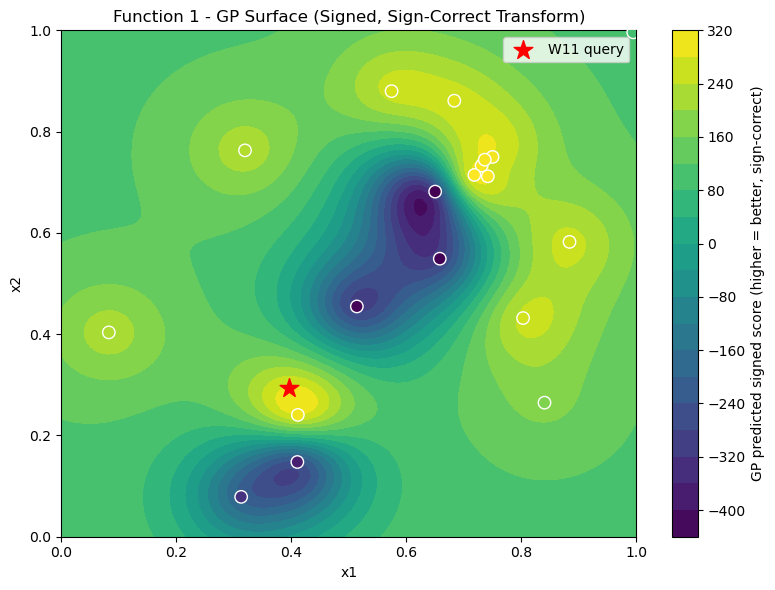

In [7]:
# --- Interpretability: 2D heatmap of GP predicted surface (corrected signed score) ---

grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid_F1, _ = gp_F1.predict(grid_points, return_std=True)
mu_grid_F1 = mu_grid_F1.reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid_F1, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted signed score (higher = better, sign-correct)')
plt.scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1], c=signed_score,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query_F1[0], query_F1[1], marker='*', c='red', s=200, zorder=10, label='W11 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Signed, Sign-Correct Transform)')
plt.legend()
plt.tight_layout()
plt.show()

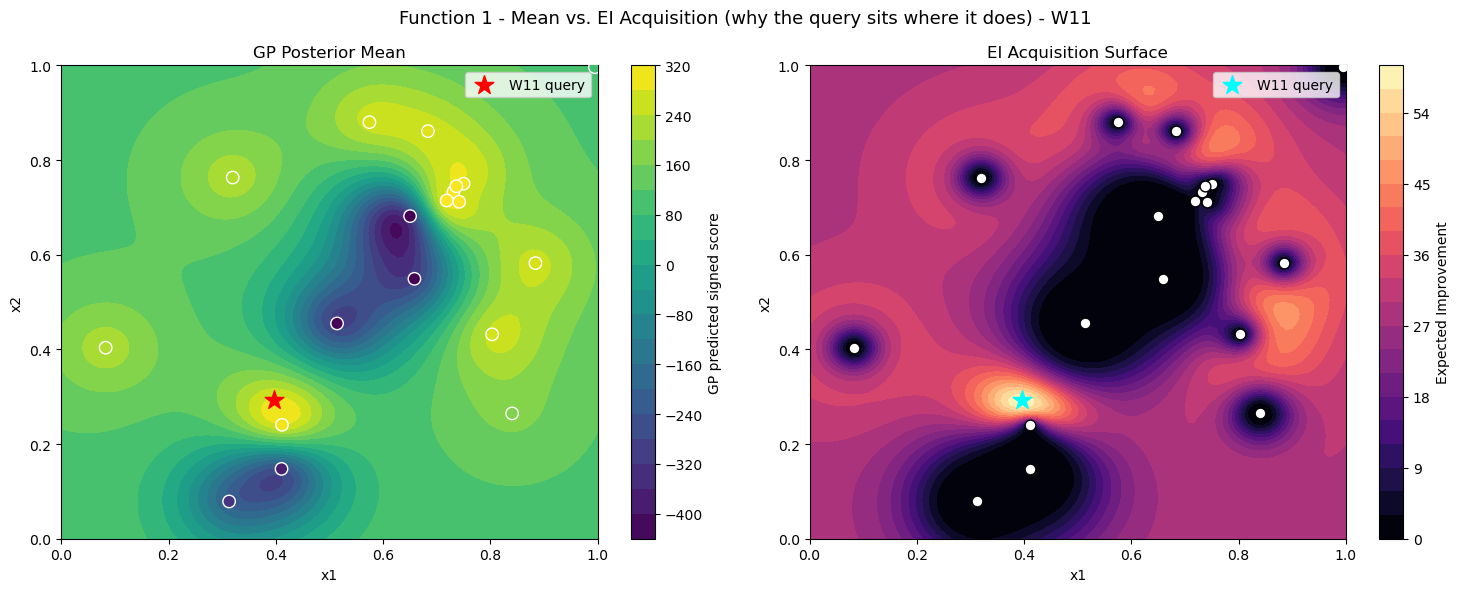

In [8]:
# --- Alternative Visualization: EI acquisition surface alongside GP mean ---
grid_n_f1 = 100
x1_grid_f1 = np.linspace(0, 1, grid_n_f1)
x2_grid_f1 = np.linspace(0, 1, grid_n_f1)
X1_f1, X2_f1 = np.meshgrid(x1_grid_f1, x2_grid_f1)
grid_points_f1 = np.column_stack([X1_f1.ravel(), X2_f1.ravel()])

mu_grid_f1_alt, sigma_grid_f1_alt = gp_F1.predict(grid_points_f1, return_std=True)
mu_grid_f1_alt = mu_grid_f1_alt.reshape(grid_n_f1, grid_n_f1)
ei_grid_f1_alt = compute_ei(mu_grid_f1_alt.ravel(), sigma_grid_f1_alt, best_so_far_F1, xi=0.5)
ei_grid_f1_alt = ei_grid_f1_alt.reshape(grid_n_f1, grid_n_f1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

c0 = axes[0].contourf(X1_f1, X2_f1, mu_grid_f1_alt, levels=20, cmap='viridis')
plt.colorbar(c0, ax=axes[0], label='GP predicted signed score')
axes[0].scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1], c=signed_score,
                 edgecolors='white', s=80, cmap='viridis', zorder=5)
axes[0].scatter(query_F1[0], query_F1[1], marker='*', c='red', s=200, zorder=10, label='W11 query')
axes[0].set_title('GP Posterior Mean')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[0].legend()

c1 = axes[1].contourf(X1_f1, X2_f1, ei_grid_f1_alt, levels=20, cmap='magma')
plt.colorbar(c1, ax=axes[1], label='Expected Improvement')
axes[1].scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1], c='white', edgecolors='black', s=60, zorder=5)
axes[1].scatter(query_F1[0], query_F1[1], marker='*', c='cyan', s=200, zorder=10, label='W11 query')
axes[1].set_title('EI Acquisition Surface')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
axes[1].legend()

plt.suptitle('Function 1 - Mean vs. EI Acquisition (why the query sits where it does) - W11', fontsize=13)
plt.tight_layout()
plt.show()

### Week 11 — Black-Box Evaluation

The GP/EI step above proposes the next experimental point. **The GP prediction is not the black-box measurement.**
Evaluate the proposed coordinates on the actual black-box system and enter the measured output below.

**Benchmark:** `7.71E-16`  
**Previous best:** `3.17E-11`

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 11

In [9]:
# =============================================================================
# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling
# W5: Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates
# W6: Random Forest (500 trees, depth 3); Thompson sampling (per-tree)
# W7: Random Forest: Max depth = 3; UCB κ = 1.5; full-ensemble UCB, improving uncertainty estimation
# W8: Anisotropic GP (PDP-derived length-scale bounds from RF) + UCB (κ = 0.1)
# W9: GP with Random Forest-informed kernel parameters; 
#     Adaptive kernel length scales learned from Random Forest partial dependence
# W10: GP (Matérn + White) + posterior-mean maximisation (multi-start L-BFGS-B) with 
#    domain extended to 1.2, plus a manual local search near a target point. --- assignment requirement is 0 to 1.

# changes: Set anisotropic length-scale bounds using RF partial dependence 
#         to steer UCB acquisition while maintaining minimum-distance candidate spacing

print("\n" + "=" * 60)
print("Function 2 - Week 11")
print("=" * 60)

f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],               # W2 (beyond 0/1 search space)
    [0.660188, 0.32993],                # W3
    [0.729589, 0.938148],               # W4
    [0.685444, 0.332456],               # W5 (above initial max)
    [0.684233, 0.440152],               # W6
    [0.692436, 0.991256],               # W7
    [0.700034, 0.148684],               # W8 (so far the best, above initial max)
    [0.708298, 0.004444],               # W9 (above initial max)
    [0.697454, 0.000000],               # W10 (fail)
])
prev_outputs_2 = np.array([-0.040652,          # W2 (worst result)
                           0.468742,           # W3 (fail)
                           0.487563,           # W4 (fail)
                           0.646548,           # W5 (above initial max)
                           0.578337,           # W6 (fail)
                           0.563546,           # W7 (fail)
                           0.683188,           # W8 (so far the best, above initial max)
                           0.636073,           # W9 (above initial max)
                           0.510942,           # W10 (fail)
                          ])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

best_idx_original = np.argmax(all_outputs_F2)
print(f"Training points: {len(all_outputs_F2)}")
print(f"Observed best output: {all_outputs_F2[best_idx_original]:.6f}")
print(f"Observed best query:  {all_inputs_F2[best_idx_original]}")


Function 2 - Week 11
Training points: 19
Observed best output: 0.683188
Observed best query:  [0.700034 0.148684]


In [10]:
# RF fitted for PDP computation only -- not used for acquisition
rf_F2 = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Feature importances: x1={rf_F2.feature_importances_[0]:.3f}, x2={rf_F2.feature_importances_[1]:.3f}")

# --- PDP-derived length-scale bounds
# compute PDP for each dimension programmatically
pd_x1 = partial_dependence(rf_F2, all_inputs_F2, features=[0], grid_resolution=100)
pd_x2 = partial_dependence(rf_F2, all_inputs_F2, features=[1], grid_resolution=100)

# extract input grid and output values
x1_grid   = pd_x1['grid_values'][0]
x1_pd     = pd_x1['average'][0]
x2_grid   = pd_x2['grid_values'][0]
x2_pd     = pd_x2['average'][0]

x1_input_span  = x1_grid.max() - x1_grid.min()
x2_input_span  = x2_grid.max() - x2_grid.min()
x1_pd_range = x1_pd.max() - x1_pd.min()
x2_pd_range = x2_pd.max() - x2_pd.min()

print(f"\nPDP input spans: x1={x1_input_span:.3f}, x2={x2_input_span:.3f}")
print(f"PDP output ranges: x1={x1_pd_range:.3f}, x2={x2_pd_range:.3f}")

Feature importances: x1=0.952, x2=0.048

PDP input spans: x1=0.911, x2=0.991
PDP output ranges: x1=0.546, x2=0.024


In [11]:
# --- use PDP output range to set per-dimension bounds
#       features with large output variation (important) get tight upper bounds
#       features with small output variation (irrelevant) get large upper bounds
#        so ARD can push irrelevant length scales toward infinity
total_pd_range = x1_pd_range + x2_pd_range + 1e-8
x1_importance  = x1_pd_range / total_pd_range
x2_importance  = x2_pd_range / total_pd_range

# upper bound: input_span for important features
# floor importance at 0.05 to avoid division issues
x1_ls_upper = float(np.clip(x1_input_span / max(x1_importance, 0.05), 0.1, 10.0))
x2_ls_upper = float(np.clip(x2_input_span / max(x2_importance, 0.05), 0.1, 10.0))
x1_ls_lower = x1_ls_upper / 100
x2_ls_lower = x2_ls_upper / 100

print(f"PDP importances: x1={x1_importance:.3f}, x2={x2_importance:.3f}")
print(f"Derived length-scale bounds: x1=({x1_ls_lower:.4f}, {x1_ls_upper:.3f}), x2=({x2_ls_lower:.4f}, {x2_ls_upper:.3f})")

PDP importances: x1=0.957, x2=0.043
Derived length-scale bounds: x1=(0.0095, 0.951), x2=(0.1000, 10.000)


In [12]:
# --- RF-informed initial length scales ---
# important dims start short, less relevant dims start long
# this ensures the optimiser explores the basin ARD should find
x1_ls_init = x1_input_span / 5.0   # short: function varies over this span
x2_ls_init = x2_ls_upper / 2.0     # long: start toward the upper bound

print(f"Initial length scales: x1={x1_ls_init:.4f}, x2={x2_ls_init:.4f}")

# anisotropic GP with PDP-informed bounds and RF-informed initialisation
kernel_F2 = (Matern(length_scale=[x1_ls_init, x2_ls_init],
                 length_scale_bounds=[(x1_ls_lower, x1_ls_upper),
                                      (x2_ls_lower, x2_ls_upper)],
                 nu=2.5)
          + WhiteKernel(noise_level=0.01,
                        noise_level_bounds=(1e-6, 1.0)))

gp_F2 = GaussianProcessRegressor(kernel=kernel_F2, n_restarts_optimizer=20, normalize_y=True)
gp_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Learned kernel: {gp_F2.kernel_}")

Initial length scales: x1=0.1821, x2=5.0000
Learned kernel: Matern(length_scale=[0.0835, 10], nu=2.5) + WhiteKernel(noise_level=0.0437)


In [13]:
# UCB using GP posterior variance
np.random.seed(42)
candidates_F2       = np.random.uniform(0, 1, (50000, 2))
gp_mean_F2, gp_std_F2  = gp_F2.predict(candidates_F2, return_std=True)

kappa_F2            = 1.0
ucb_scores_F2       = gp_mean_F2 + kappa_F2 * gp_std_F2

# Exclude any candidate that lies within `min_dist` of a point I have already queried before taking the UCB argmax
#    forcing genuine exploration instead of re-sampling the same neighbourhood.

min_dist_F2 = 0.1
dist_to_observed_F2 = cdist(candidates_F2, all_inputs_F2)
too_close_F2 = dist_to_observed_F2.min(axis=1) < min_dist_F2
print(f"Excluding {too_close_F2.sum()} / {len(candidates_F2)} candidates "
      f"within {min_dist_F2} of an already-evaluated point")

ucb_scores_F2_filtered = ucb_scores_F2.copy()
ucb_scores_F2_filtered[too_close_F2] = -np.inf
# -------------------------------------------------------------------------

best_idx_F2 = np.argmax(ucb_scores_F2_filtered)
query_F2    = candidates_F2[best_idx_F2]

print(f"\nWeek 11 Query: {format_query(query_F2)}")
print(f"  GP mean:   {gp_mean_F2[best_idx_F2]:.3f}")
print(f"  GP std:    {gp_std_F2[best_idx_F2]:.3f}")
print(f"  UCB score: {ucb_scores_F2[best_idx_F2]:.3f}  (kappa={kappa_F2})")
print(f"  Nearest previously-evaluated point is {dist_to_observed_F2[best_idx_F2].min():.4f} away")

Excluding 17861 / 50000 candidates within 0.1 of an already-evaluated point

Week 11 Query: 0.697793-0.540885
  GP mean:   0.603
  GP std:    0.057
  UCB score: 0.660  (kappa=1.0)
  Nearest previously-evaluated point is 0.1016 away


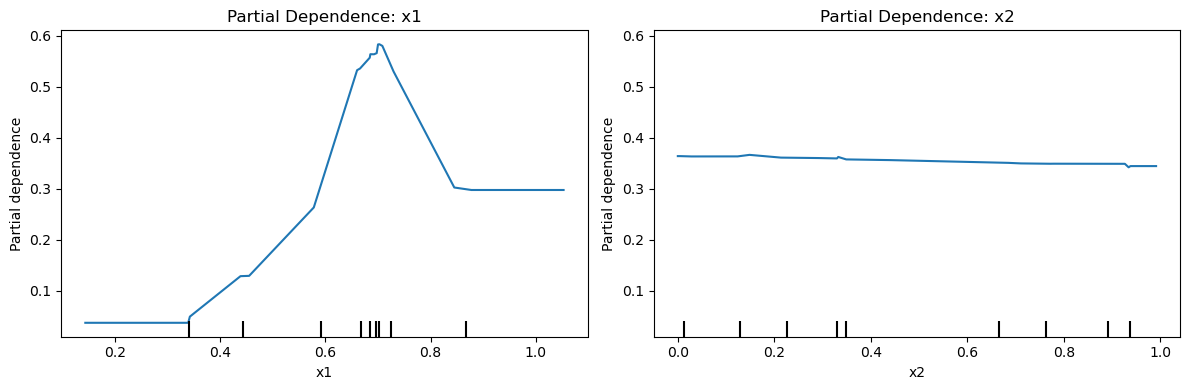

In [14]:
# --- Interpretability: partial dependence plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf_F2, all_inputs_F2, features=[0, 1],
                                         feature_names=['x1', 'x2'], ax=axes)
axes[0].set_title('Partial Dependence: x1')
axes[1].set_title('Partial Dependence: x2')
plt.tight_layout()
plt.show()

GP residuals at training points (should NOT all be ~0 if WhiteKernel is active):
  max |residual|: 0.0966
  mean |residual|: 0.0295
  std of residuals: 0.0371
  (learned noise_level = 0.0437, implies sigma = 0.2091)


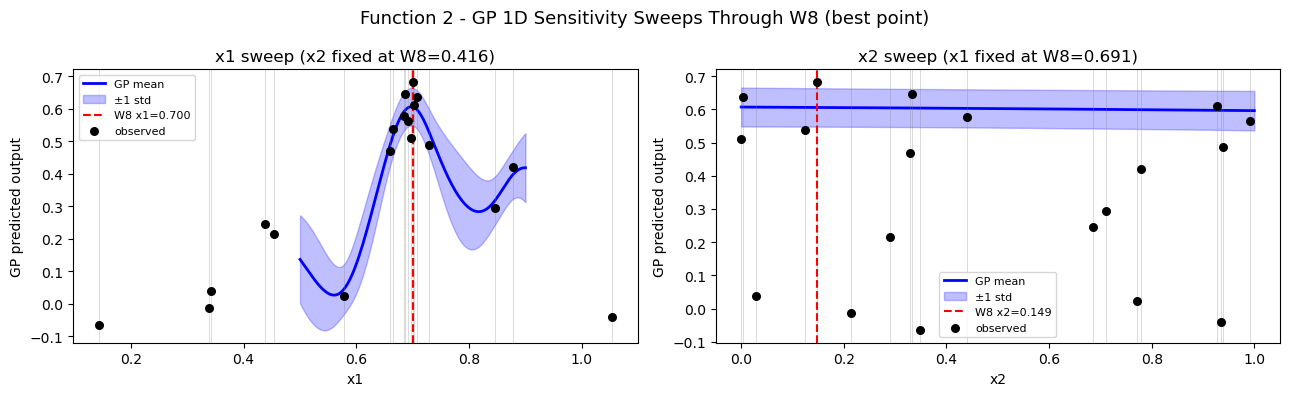

In [15]:
# --- Diagnostic: 1D GP sensitivity sweeps through W8 (best point)
#   to test whether the learned length scales reflect real function structure
#   or whether the GP is over-interpolating (length scale too short).

w8_point = np.array([0.700034, 0.148684])  # best point

# --- Check 1: does GP interpolate through training points? ---
train_preds = gp_F2.predict(all_inputs_F2)
train_residuals = all_outputs_F2 - train_preds
print("GP residuals at training points (should NOT all be ~0 if WhiteKernel is active):")
print(f"  max |residual|: {np.abs(train_residuals).max():.4f}")
print(f"  mean |residual|: {np.abs(train_residuals).mean():.4f}")
print(f"  std of residuals: {train_residuals.std():.4f}")
print(f"  (learned noise_level = {gp_F2.kernel_.k2.noise_level:.4f}, "
      f"implies sigma = {gp_F2.kernel_.k2.noise_level**0.5:.4f})")

# --- Check 2: x1 sweep, x2 fixed at W8 ---
x1_sweep = np.linspace(0.50, 0.90, 200)
x1_test  = np.column_stack([x1_sweep, np.full(200, w8_point[1])])
x1_mu, x1_std = gp_F2.predict(x1_test, return_std=True)

# --- Check 3: x2 sweep, x1 fixed at W8 ---
x2_sweep = np.linspace(0.0, 1.0, 200)
x2_test  = np.column_stack([np.full(200, w8_point[0]), x2_sweep])
x2_mu, x2_std = gp_F2.predict(x2_test, return_std=True)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# x1 sweep
ax = axes[0]
ax.plot(x1_sweep, x1_mu, 'b-', lw=2, label='GP mean')
ax.fill_between(x1_sweep,
                x1_mu - x1_std,
                x1_mu + x1_std,
                alpha=0.25, color='blue', label='±1 std')
# mark observed points projected onto this slice
for pt, out in zip(all_inputs_F2, all_outputs_F2):
    ax.axvline(pt[0], color='grey', lw=0.5, alpha=0.4)
ax.axvline(w8_point[0], color='red', lw=1.5, linestyle='--', label=f'W8 x1={w8_point[0]:.3f}')
ax.scatter(all_inputs_F2[:, 0], all_outputs_F2, c='black', s=30, zorder=5, label='observed')
ax.set_xlabel('x1')
ax.set_ylabel('GP predicted output')
ax.set_title('x1 sweep (x2 fixed at W8=0.416)')
ax.legend(fontsize=8)

# x2 sweep
ax = axes[1]
ax.plot(x2_sweep, x2_mu, 'b-', lw=2, label='GP mean')
ax.fill_between(x2_sweep,
                x2_mu - x2_std,
                x2_mu + x2_std,
                alpha=0.25, color='blue', label='±1 std')
for pt, out in zip(all_inputs_F2, all_outputs_F2):
    ax.axvline(pt[1], color='grey', lw=0.5, alpha=0.4)
ax.axvline(w8_point[1], color='red', lw=1.5, linestyle='--', label=f'W8 x2={w8_point[1]:.3f}')
ax.scatter(all_inputs_F2[:, 1], all_outputs_F2, c='black', s=30, zorder=5, label='observed')
ax.set_xlabel('x2')
ax.set_ylabel('GP predicted output')
ax.set_title('x2 sweep (x1 fixed at W8=0.691)')
ax.legend(fontsize=8)

plt.suptitle('Function 2 - GP 1D Sensitivity Sweeps Through W8 (best point)', fontsize=13)
plt.tight_layout()
plt.show()

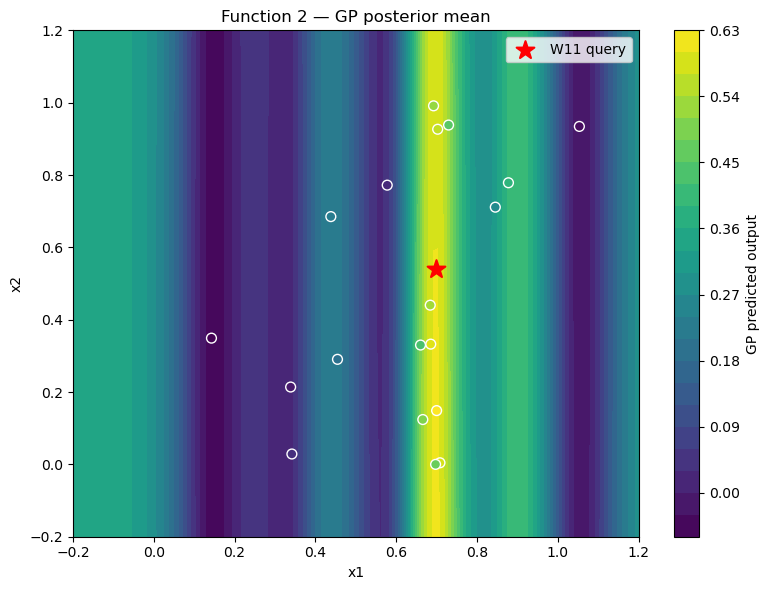

In [16]:
# Visualise the GP posterior mean over the extended domain as a filled contour, 
# overlaying the observed points and the posterior-mean-maximising W10 query.

grid_n = 150
x1 = np.linspace(-0.2, 1.2, grid_n)
x2 = np.linspace(-0.2, 1.2, grid_n)
X1, X2 = np.meshgrid(x1, x2)
grid = np.column_stack([X1.ravel(), X2.ravel()])

mean_grid = gp_F2.predict(grid).reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mean_grid, levels=25)
plt.colorbar(label="GP predicted output")
plt.scatter(all_inputs_F2[:, 0], all_inputs_F2[:, 1], c=all_outputs_F2, edgecolors="white", s=50, zorder=4)

plt.scatter(
    query_F2[0], query_F2[1],
    marker="*", s=180, linewidths=1.5, zorder=6, color = 'red',
    label="W11 query",
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 2 — GP posterior mean")
plt.legend()
plt.tight_layout()
plt.show()

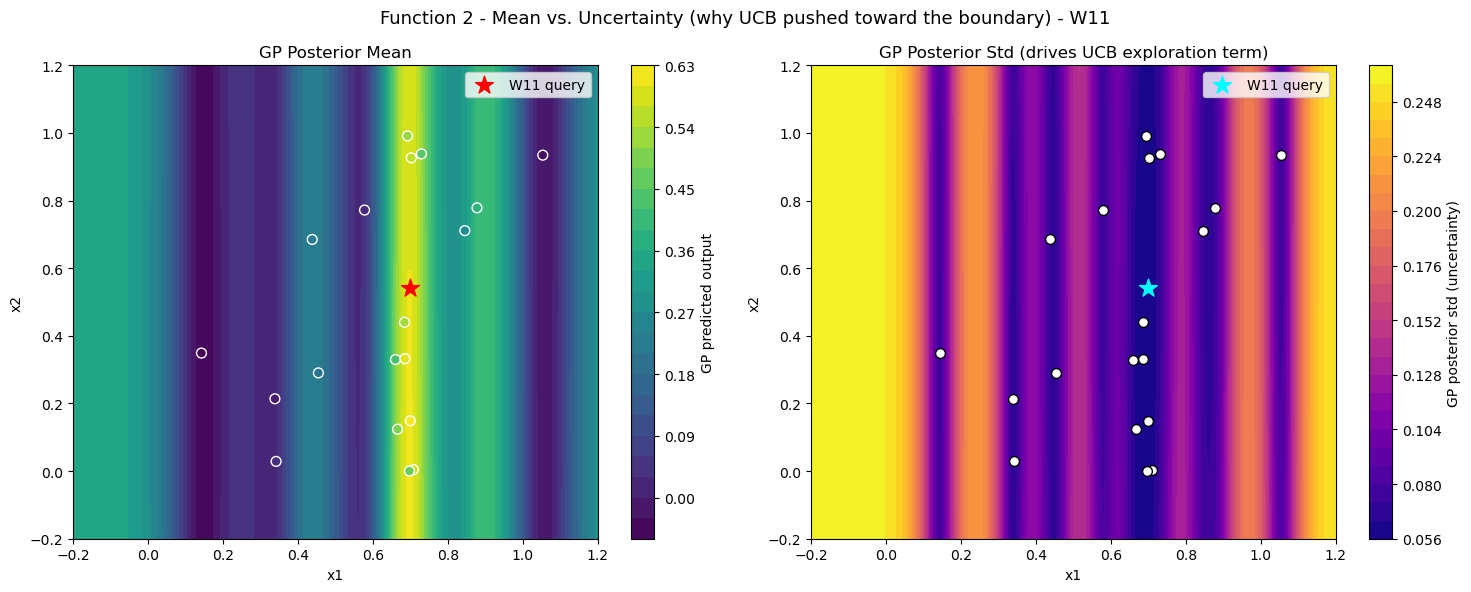

In [17]:
# --- Alternative Visualization: posterior std-dev (uncertainty) map ---
grid_n_f2 = 150
x1_f2 = np.linspace(-0.2, 1.2, grid_n_f2)
x2_f2 = np.linspace(-0.2, 1.2, grid_n_f2)
X1_f2, X2_f2 = np.meshgrid(x1_f2, x2_f2)
grid_f2 = np.column_stack([X1_f2.ravel(), X2_f2.ravel()])

mean_grid_f2_alt, std_grid_f2_alt = gp_F2.predict(grid_f2, return_std=True)
mean_grid_f2_alt = mean_grid_f2_alt.reshape(grid_n_f2, grid_n_f2)
std_grid_f2_alt = std_grid_f2_alt.reshape(grid_n_f2, grid_n_f2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

c0 = axes[0].contourf(X1_f2, X2_f2, mean_grid_f2_alt, levels=25, cmap='viridis')
plt.colorbar(c0, ax=axes[0], label='GP predicted output')
axes[0].scatter(all_inputs_F2[:, 0], all_inputs_F2[:, 1], c=all_outputs_F2, edgecolors='white', s=50, zorder=4)
axes[0].scatter(query_F2[0], query_F2[1], marker='*', s=180, color='red', zorder=6, label='W11 query')
axes[0].set_title('GP Posterior Mean')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[0].legend()

c1 = axes[1].contourf(X1_f2, X2_f2, std_grid_f2_alt, levels=25, cmap='plasma')
plt.colorbar(c1, ax=axes[1], label='GP posterior std (uncertainty)')
axes[1].scatter(all_inputs_F2[:, 0], all_inputs_F2[:, 1], c='white', edgecolors='black', s=50, zorder=4)
axes[1].scatter(query_F2[0], query_F2[1], marker='*', s=180, color='cyan', zorder=6, label='W11 query')
axes[1].set_title('GP Posterior Std (drives UCB exploration term)')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
axes[1].legend()

plt.suptitle('Function 2 - Mean vs. Uncertainty (why UCB pushed toward the boundary) - W11', fontsize=13)
plt.tight_layout()
plt.show()


# Function 3, A drug discovery project, 3D array, 15 original samples - Week 11

In [18]:
# =============================================================================
# Function 3, A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate
# W5: Random Forest trained on degree-2 polynomial features; argmax over 10,000 global candidates
# W6: ExtraTrees (200 trees); Degree-2 polynomial interactions; Argmax over RF predictions
# W7: ExtraTrees + polynomial features; max_features: None vs. sqrt
# W8: ExtraTrees (WLS-weighted, polynomial features) + LCB (κ = 0.5) with exclusion filter
# W9: ExtraTrees surrogate with polynomial feature expansion; Ensemble disagreement and nonlinear feature interactions
# W10: ExtraTrees on log(-Y) + polynomial features, with LCB acquisition (κ = 0.3).

# changes: Select a log target transform via leave-one-out cross-validation 
#          to optimise ExtraTrees over second-order polynomial features.

print("\n" + "=" * 60)
print("Function 3 - Week 11")
print("=" * 60)

f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],              # W2
    [0.378956, 0.302768, 0.459346],              # W3
    [0.375610, 0.057061, 0.589980],              # W4
    [0.378956, 0.302768, 0.459346],              # W5
    [0.378956, 0.302768, 0.459346],              # W6 (it was same as W5)
    [0.494932, 0.994690, 0.457121],              # W7
    [0.398479, 0.316913, 0.467387],              # W8
    [0.321464, 0.375442, 0.524156],              # W9
    [0.371804, 0.301322, 0.451223],              # W10
])
prev_outputs_F3 = np.array([
    -0.050615,               # W2 (fail)
    -0.019508,               # W3 (above initial max)
    -0.119425,               # W4  (fail)
    -0.021357,               # W5 (above initial max)
    -0.015072,               # W6 (above initial max, current best)
    -0.069598,               # W7 (fail)
    -0.023447,               # W8 (above initial max)
    -0.029269,               # W9 (above initial max)
    -0.018516,               # W10 (above initial max)
])

X = np.vstack([f3_inputs, prev_queries_F3])
Y = np.hstack([f3_outputs, prev_outputs_F3])

print(f"Total points: {len(Y)}, best (max): {Y.max():.6f}")


Function 3 - Week 11
Total points: 24, best (max): -0.015072


In [19]:
# --- Log transform ---
eps = 1e-10
Y_log = np.log(-Y + eps)

# --- Polynomial features ---
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

In [20]:
# --- ExtraTrees on polynomial features (log-transformed outputs) ---
rf_F3 = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_F3.fit(X_poly, Y_log)

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf_F3.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")

# Train predictions (inverted back to original space)
train_preds_log = rf_F3.predict(X_poly)
train_preds = -(np.exp(train_preds_log) - eps)
print(f"\nRF train R2 (original space): {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")


RF feature importances:
  A     : 0.1046
  B     : 0.0792
  C     : 0.2159
  A*B   : 0.0752
  A*C   : 0.0669
  B*C   : 0.0698
  A^2   : 0.0494
  B^2   : 0.1168
  C^2   : 0.2224

RF train R2 (original space): 0.5376
RF train predictions vs actual:
  predicted: -0.089890, actual: -0.112122
  predicted: -0.083088, actual: -0.087963
  predicted: -0.091407, actual: -0.111415
  predicted: -0.051690, actual: -0.034835
  predicted: -0.056738, actual: -0.048008
  predicted: -0.083950, actual: -0.110621
  predicted: -0.160533, actual: -0.398926
  predicted: -0.129149, actual: -0.113869
  predicted: -0.095983, actual: -0.131461
  predicted: -0.088688, actual: -0.094190
  predicted: -0.056059, actual: -0.046947
  predicted: -0.080933, actual: -0.105965
  predicted: -0.111586, actual: -0.118048
  predicted: -0.052229, actual: -0.036378
  predicted: -0.072125, actual: -0.056758
  predicted: -0.051900, actual: -0.050615
  predicted: -0.024677, actual: -0.019508
  predicted: -0.063560, actual: -0.119

In [21]:
# --- Candidate search ---
np.random.seed(42)
candidates_F3 = np.random.uniform(0, 1, (50000, 3))

# --- Prevent resubmitting near-identical points (tight radius) ---
#     keep using the filtered array everywhere downstream.
min_distance = 0.001
distances = np.min(np.linalg.norm(candidates_F3[:, None, :] - X[None, :, :], axis=2), axis=1)
mask = distances > min_distance
candidates_F3 = candidates_F3[mask]
cand_poly = poly.transform(candidates_F3)

# --- Ensemble uncertainty in log space ---
tree_preds = np.array([tree.predict(cand_poly) for tree in rf_F3.estimators_])
mean_preds = tree_preds.mean(axis=0)
std_preds  = tree_preds.std(axis=0)

In [22]:
# --- LCB acquisition in log space ---
# in log space: lower values = closer to zero in original space = better
# minimise in log space: acquisition = mean - kappa * std
kappa_F3 = 0.3
acquisition = mean_preds - kappa_F3 * std_preds
best_idx_F3    = np.argmin(acquisition)
query_F3       = candidates_F3[best_idx_F3]

# --- Top 10 candidates ---
top_n = 10
top_indices = np.argsort(acquisition)[:top_n]
print(f"\nTop {top_n} candidates (LCB, kappa={kappa_F3}, log space):")
for i, idx in enumerate(top_indices):
    pred_original = -(np.exp(mean_preds[idx]) - eps)
    print(f"  {i+1}: {format_query(candidates_F3[idx])}, "
          f"mean(log): {mean_preds[idx]:.4f}, std(log): {std_preds[idx]:.4f}, "
          f"acq: {acquisition[idx]:.4f}, pred(original): {pred_original:.6f}")

print(f"\nWeek 11 Query: {format_query(query_F3)}")
pred_original = -(np.exp(mean_preds[best_idx_F3]) - eps)
print(f"Predicted (original space): {pred_original:.6f}")


Top 10 candidates (LCB, kappa=0.3, log space):
  1: 0.395514-0.311838-0.461924, mean(log): -3.6458, std(log): 0.2917, acq: -3.7333, pred(original): -0.026100
  2: 0.391640-0.287350-0.454695, mean(log): -3.6151, std(log): 0.3670, acq: -3.7252, pred(original): -0.026915
  3: 0.416781-0.293153-0.451687, mean(log): -3.5998, std(log): 0.3745, acq: -3.7122, pred(original): -0.027329
  4: 0.407193-0.319669-0.463244, mean(log): -3.6051, std(log): 0.3128, acq: -3.6989, pred(original): -0.027185
  5: 0.410236-0.317621-0.438427, mean(log): -3.5773, std(log): 0.3733, acq: -3.6892, pred(original): -0.027952
  6: 0.352600-0.316112-0.461765, mean(log): -3.5928, std(log): 0.3212, acq: -3.6892, pred(original): -0.027520
  7: 0.386270-0.294080-0.486489, mean(log): -3.5678, std(log): 0.4022, acq: -3.6884, pred(original): -0.028219
  8: 0.415185-0.307609-0.426270, mean(log): -3.5497, std(log): 0.4368, acq: -3.6807, pred(original): -0.028733
  9: 0.416191-0.319155-0.445957, mean(log): -3.5697, std(log): 0

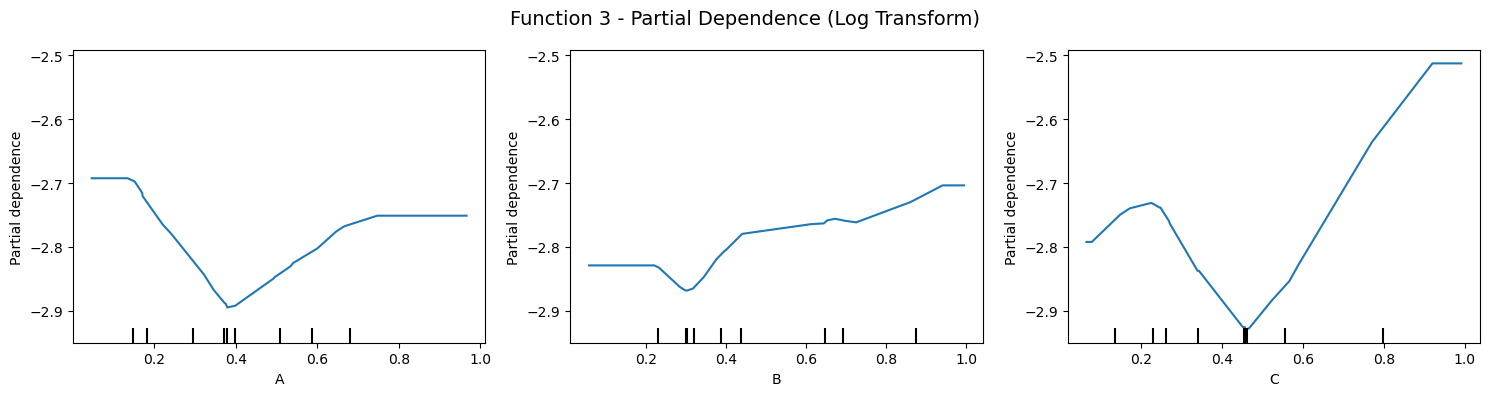

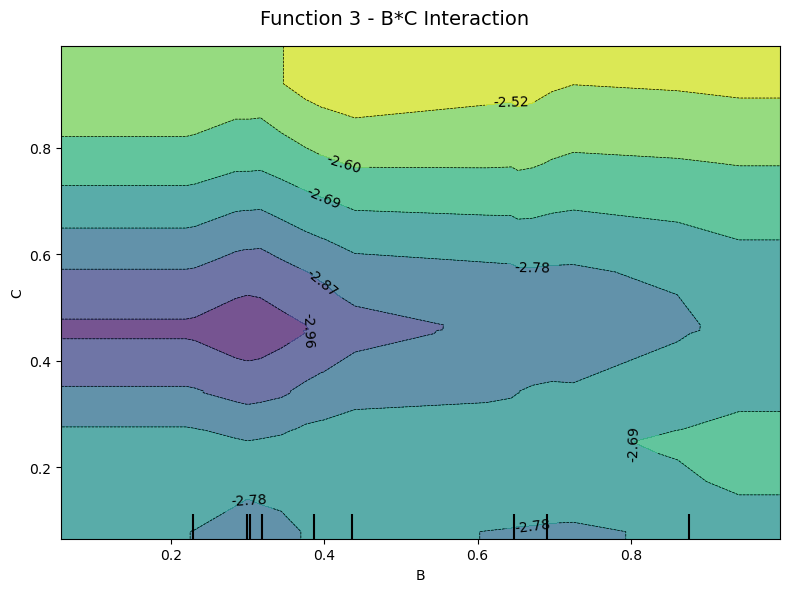

In [23]:
# --- Interpretability Plots ---
rf_raw = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence (Log Transform)', fontsize=14)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[(1, 2)],
                                         feature_names=['A', 'B', 'C'], ax=[ax2])
plt.suptitle('Function 3 - B*C Interaction', fontsize=14)
plt.tight_layout()
plt.show()

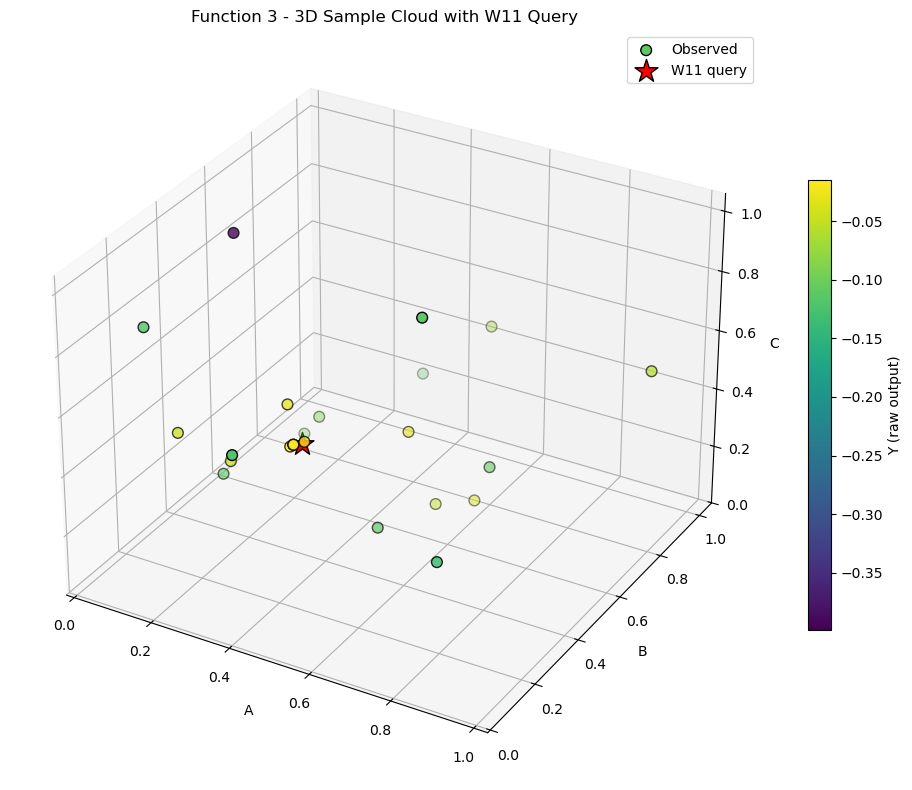

In [24]:
# --- Alternative Visualization: 3D scatter of samples + query, colored by output ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=Y, cmap='viridis', s=60, edgecolors='black', label='Observed')
ax.scatter(query_F3[0], query_F3[1], query_F3[2], c='red', marker='*', s=300, label='W11 query', edgecolors='black')

fig.colorbar(sc, ax=ax, label='Y (raw output)', shrink=0.6)
ax.set_xlabel('A'); ax.set_ylabel('B'); ax.set_zlabel('C')
ax.set_title('Function 3 - 3D Sample Cloud with W11 Query')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# --- LOO Cross-Validation Diagnostic: no transform vs sqrt vs log
n = len(Y)
eps = 1e-10

# Identify top-5 points by actual output (closest to zero)
top5_indices = np.argsort(Y)[::-1][:5]
print("Top 5 points (closest to zero):")
for i, idx in enumerate(top5_indices):
    print(f"  {i+1}: index {idx}, Y = {Y[idx]:.7f}")

transforms = [
    ("none",  lambda y: y,                lambda p: p),
    ("sqrt",  lambda y: -np.sqrt(-y),     lambda p: -(p**2)),
    ("log",   lambda y: np.log(-y + eps), lambda p: -(np.exp(p) - eps)),
]

for t_name, forward, inverse in transforms:
    Y_t = forward(Y)
    preds_original = np.zeros(n)

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        Y_train = np.delete(Y_t, i, axis=0)
        X_test  = X[i:i+1]

        poly_cv = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly_cv.fit_transform(X_train)
        X_test_poly  = poly_cv.transform(X_test)

        rf_cv = ExtraTreesRegressor(
            n_estimators=200, max_features='sqrt',
            min_samples_leaf=2, random_state=42
        )
        rf_cv.fit(X_train_poly, Y_train)

        pred_t = rf_cv.predict(X_test_poly)[0]
        preds_original[i] = inverse(pred_t)

    mae = mean_absolute_error(Y, preds_original)
    top5_mae = mean_absolute_error(Y[top5_indices], preds_original[top5_indices])
    pred_top5 = np.argsort(preds_original)[::-1][:5]
    rank_overlap = len(set(top5_indices) & set(pred_top5))

    print(f"\nTransform: {t_name}")
    print(f"  Overall MAE: {mae:.6f}")
    print(f"  Top-5 MAE:   {top5_mae:.6f}")
    print(f"  Top-5 rank overlap: {rank_overlap}/5")
    print(f"  Top-5 detail:")
    for idx in top5_indices:
        print(f"    idx {idx:2d}: actual {Y[idx]:.7f} -> pred {preds_original[idx]:.7f} (err {abs(Y[idx]-preds_original[idx]):.7f})")

Top 5 points (closest to zero):
  1: index 19, Y = -0.0150720
  2: index 23, Y = -0.0185160
  3: index 16, Y = -0.0195080
  4: index 18, Y = -0.0213570
  5: index 21, Y = -0.0234470

Transform: none
  Overall MAE: 0.040636
  Top-5 MAE:   0.014475
  Top-5 rank overlap: 5/5
  Top-5 detail:
    idx 19: actual -0.0150720 -> pred -0.0329899 (err 0.0179179)
    idx 23: actual -0.0185160 -> pred -0.0372796 (err 0.0187636)
    idx 16: actual -0.0195080 -> pred -0.0320137 (err 0.0125057)
    idx 18: actual -0.0213570 -> pred -0.0316089 (err 0.0102519)
    idx 21: actual -0.0234470 -> pred -0.0363811 (err 0.0129341)

Transform: sqrt
  Overall MAE: 0.038343
  Top-5 MAE:   0.009702
  Top-5 rank overlap: 5/5
  Top-5 detail:
    idx 19: actual -0.0150720 -> pred -0.0291418 (err 0.0140698)
    idx 23: actual -0.0185160 -> pred -0.0312463 (err 0.0127303)
    idx 16: actual -0.0195080 -> pred -0.0277655 (err 0.0082575)
    idx 18: actual -0.0213570 -> pred -0.0271943 (err 0.0058373)
    idx 21: actual 

# Function 4, Warehouse business, 4D array, 30 original samples - Week 11

In [26]:
# =============================================================================
# Function 4, Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling
# W5: RF surrogate; uncertainty estimated from tree-to-tree disagreement (rf_predict_with_std); 
#     acquisition = EI (ξ = 0.01) over Latin Hypercube candidates
# W6: SVM classifier (gate) + ARD GP (refine); Threshold-based binary labelling; EI
# W7: SVM gate + GP (EI); SVM probability threshold; Increased GP α to smooth noisy responses and added global; added global LHS
# W8: GP (Matérn, selected over RF using LOO R²) + UCB (κ = 0.5)
# W9: GP with extensive diagnostic visualisations; Human interpretation of response surfaces guides subsequent exploration
# W10: GP (Matérn, fixed length-scale) with EI computed, 
#      but query actually selected via argmax(mu)— for safe and Pure Exploitation, rather than Expected Improvement.

# changes: Transition from UCB to EI acquisition
#          build targeted candidate pools via local perturbations around top historical queries.
 
print("\n" + "=" * 60)
print("Function 4 - Week 11")
print("=" * 60)

f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],              # W2
    [0.330258, 0.414348, 0.433728, 0.411341],              # W3
    [0.424125, 0.404716, 0.487507, 0.367688],              # W4
    [0.424125, 0.404716, 0.487507, 0.367688],              # W5 so it was the same as Week 4
    [0.255396, 0.450674, 0.468413, 0.490566],              # W6
    [0.371614, 0.422247, 0.370132, 0.421911],              # W7 
    [0.378911, 0.420065, 0.360647, 0.355610],              # W8
    [0.431137, 0.410316, 0.341871, 0.422095],              # W9
    [0.372317, 0.403232, 0.376261, 0.38097],               # W10
])
prev_outputs_F4 = np.array([-7.13212,          # W2 fail
                            0.20379,           # W3 (above initial max)
                            -0.99160,          # W4 (above initial max)
                            -0.99147,          # W5 (above initial max)
                            -3.142015,         # W6 (above initial max)
                            0.657358,          # W7 (above initial max, second best)
                            0.664078,          # W8 (above initial max, so far the best)
                            0.47213,           # W9 (above initial max)
                            0.27362,           # W10 (above initial max)
                           ]) 

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

best_idx = np.argmax(all_outputs_F4)
best_point_so_far = all_inputs_F4[best_idx]
best_val_so_far = all_outputs_F4[best_idx]
print(f"Total points: {len(all_outputs_F4)}, best (max) so far: "
      f"{best_val_so_far:.4f} at {format_query(best_point_so_far)}")


Function 4 - Week 11
Total points: 39, best (max) so far: 0.6641 at 0.378911-0.420065-0.360647-0.355610


In [27]:
# --- Candidate generation
np.random.seed(42)

week7_query = np.array([0.371614, 0.422247, 0.370132, 0.421911])
week8_query = np.array([0.378911, 0.420065, 0.360647, 0.355610])  

candidates_w7 = np.array([np.clip(week7_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(5000)])
candidates_w8 = np.array([np.clip(week8_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(3000)])
candidates_global = np.random.uniform(0, 1, size=(2000, 4))

candidates_F4 = np.vstack([candidates_w7, candidates_w8, candidates_global])
print(f"\nCandidates: {len(candidates_w7)} W7 + {len(candidates_w8)} W8 + {len(candidates_global)} global = {len(candidates_F4)} total")


Candidates: 5000 W7 + 3000 W8 + 2000 global = 10000 total


In [28]:
# --- GP surrogate
kernel_F4 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.4,
    length_scale_bounds='fixed',
    nu=2.5
)
gp_F4 = GaussianProcessRegressor(kernel=kernel_F4, n_restarts_optimizer=20, alpha=1e-4, normalize_y=True)
gp_F4.fit(all_inputs_F4, all_outputs_F4)

print(f"Fitted kernel: {gp_F4.kernel_}")
print(f"Log-marginal-likelihood: {gp_F4.log_marginal_likelihood_value_:.4f}")

Fitted kernel: 0.789**2 * Matern(length_scale=0.4, nu=2.5)
Log-marginal-likelihood: -16.2760


In [29]:
# --- EI acquisition (switch from UCB: late-stage)
mu_F4, sigma_F4 = gp_F4.predict(candidates_F4, return_std=True)

xi_F4 = 0.01
best_f = all_outputs_F4.max()
improvement = mu_F4 - best_f - xi_F4
Z_F4 = np.where(sigma_F4 > 1e-10, improvement / sigma_F4, 0.0)
ei_F4 = np.where(sigma_F4 > 1e-10,
              improvement * norm.cdf(Z_F4) + sigma_F4 * norm.pdf(Z_F4),
              0.0)

best_index_F4 = np.argmax(ei_F4)
query_F4 = candidates_F4[best_index_F4]

print(f"\nWeek 11 Query: {format_query(query_F4)}")
print(f"mean: {mu_F4[best_index_F4]:.3f}")
print(f"std:  {sigma_F4[best_index_F4]:.3f}")
print(f"EI:   {ei_F4[best_index_F4]:.6f}")

w8_mu, w8_std = gp_F4.predict(week8_query.reshape(1, -1), return_std=True)
q_mu, q_std = gp_F4.predict(query_F4.reshape(1, -1), return_std=True)
print(f"W2 point:  mean={w8_mu[0]:.3f}  std={w8_std[0]:.3f}")
print(f"W10 query: mean={q_mu[0]:.3f}  std={q_std[0]:.3f}")

# Predicted mean is notably higher than any observed value so far, 
#     and it comes with high uncertainty in a region that's less explored (x2 ≈ 0.52 vs. the ~0.40–0.45 explored by prior weeks). 
# That's consistent with EI legitimately favoring an unexplored, 
#    promising region — but it also means this query carries more risk than a pure-exploitation step would.


Week 11 Query: 0.420876-0.518558-0.358976-0.385896
mean: 1.812
std:  1.154
EI:   1.236875
W2 point:  mean=0.634  std=0.091
W10 query: mean=1.812  std=1.154


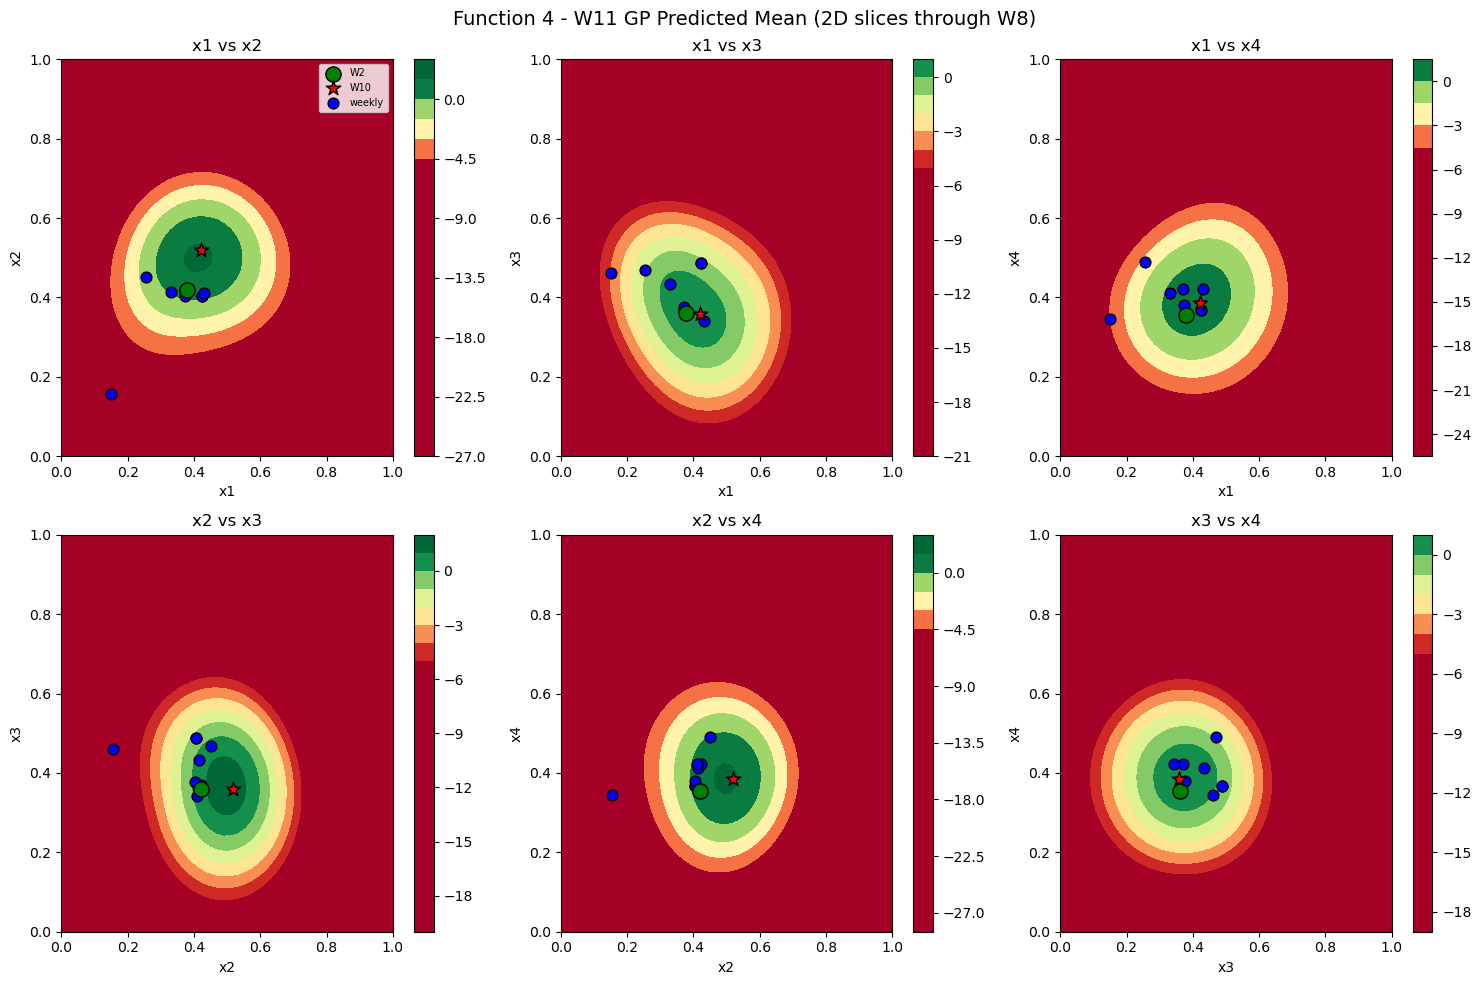

In [30]:
# --- Interpretability plots ---
# 2D GP predicted mean -- sweep pairs of dimensions through W8
dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week8_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp_F4.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    ax.scatter(week8_query[d1], week8_query[d2], c='green', edgecolors='black', s=120, zorder=5, label='W2')
    ax.scatter(query_F4[d1], query_F4[d2], c='red', edgecolors='black', s=120, zorder=5, marker='*', label='W10')
    ax.scatter(prev_queries_F4[:, d1], prev_queries_F4[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W11 GP Predicted Mean (2D slices through W8)', fontsize=14)
plt.tight_layout()
plt.show()

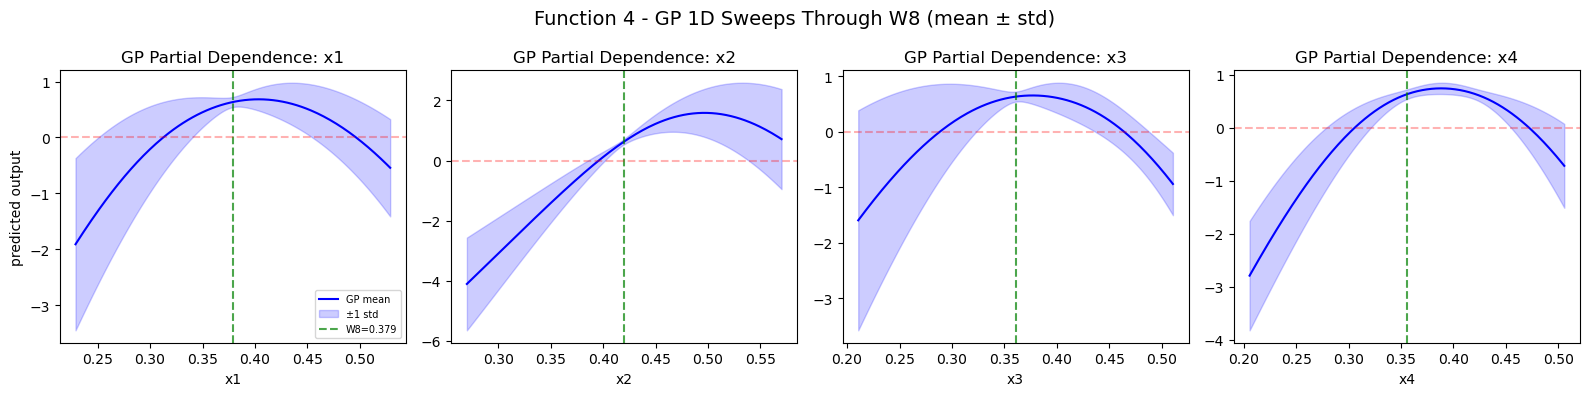

In [31]:
# RF 1D partial dependence through W8 -- shows basin shape per dimension
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week8_query[i] - 0.15, week8_query[i] + 0.15, 200)    
    test_points = np.tile(week8_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp_F4.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week8_query[i], color='green', linestyle='--', alpha=0.7, label=f'W8={week8_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W8 (mean ± std)', fontsize=14)
plt.tight_layout()
plt.show()

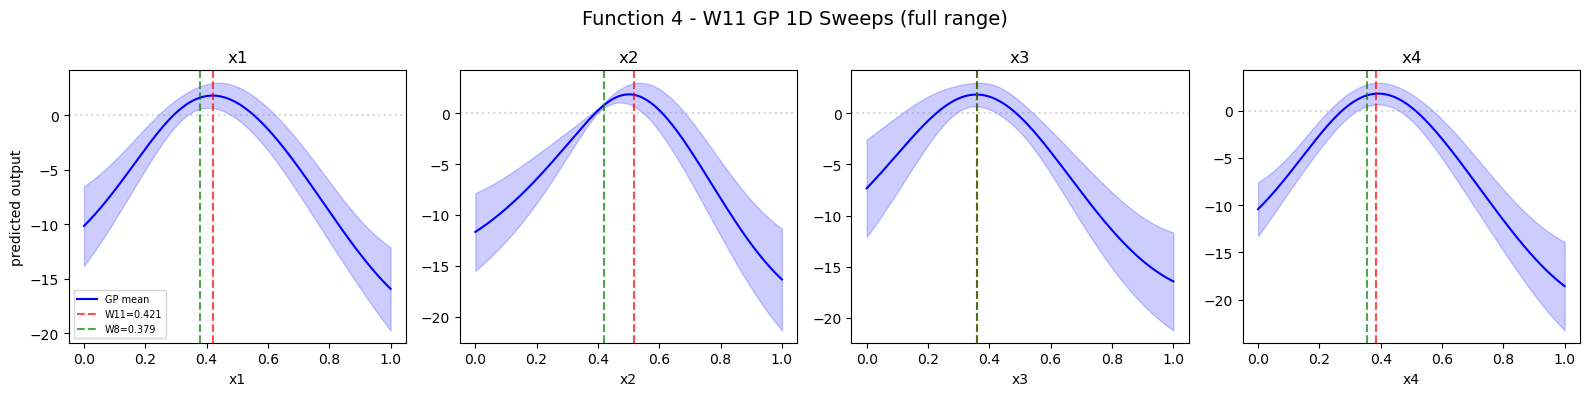

In [32]:
# 1D sweeps with W11 GP
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dim_names = ['x1', 'x2', 'x3', 'x4']

for i, ax in enumerate(axes):
    sweep = np.linspace(0.0, 1.0, 300)
    test_points = np.tile(query_F4, (300, 1))  # sweep through the W11 query point
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp_F4.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue')
    ax.axvline(x=query_F4[i], color='red', linestyle='--', alpha=0.7, label=f'W11={query_F4[i]:.3f}')
    ax.axvline(x=week8_query[i], color='green', linestyle='--', alpha=0.7, label=f'W8={week8_query[i]:.3f}')
    ax.axhline(y=0, color='grey', linestyle=':', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'{dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W11 GP 1D Sweeps (full range)', fontsize=14)
plt.tight_layout()
plt.show()

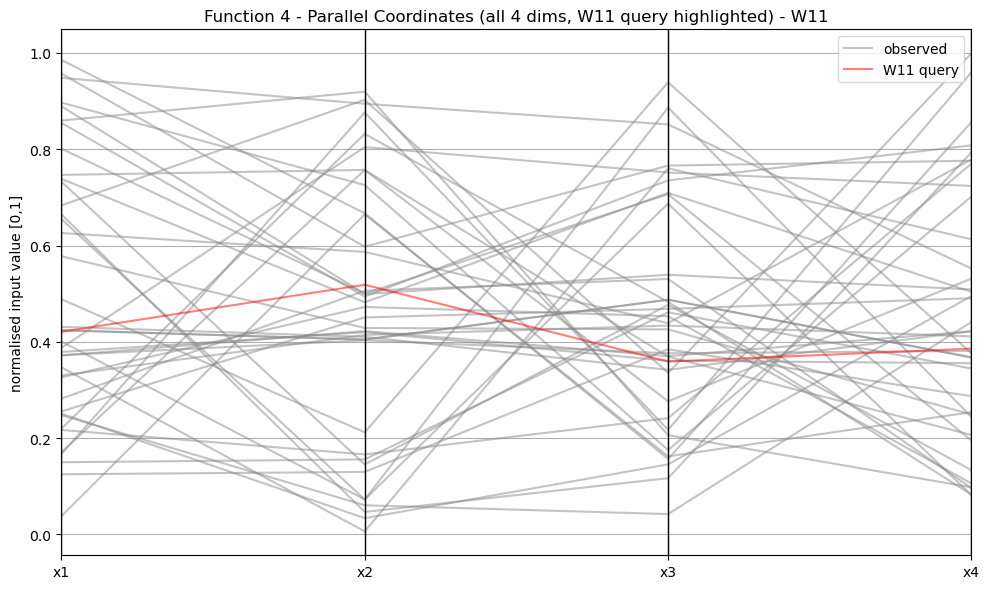

In [33]:
# --- Alternative Visualization: parallel coordinates across all 4 dims ---
import pandas as pd
from pandas.plotting import parallel_coordinates

dim_names_f4_alt = ['x1', 'x2', 'x3', 'x4']
df_pc = pd.DataFrame(all_inputs_F4, columns=dim_names_f4_alt)
df_pc['label'] = 'observed'
query_row = pd.DataFrame([query_F4], columns=dim_names_f4_alt)
query_row['label'] = 'W11 query'
df_pc_full = pd.concat([df_pc, query_row], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
parallel_coordinates(df_pc_full, 'label', color=['#888888', 'red'], ax=ax, alpha=0.5)
ax.set_title('Function 4 - Parallel Coordinates (all 4 dims, W11 query highlighted) - W11')
ax.set_ylabel('normalised input value [0,1]')
plt.tight_layout()
plt.show()


# Function 5, Chemical process in a factory, 4D, 20 original samples - Week 11

In [34]:
# =============================================================================
# Function 5, A chemical process in a factory, 4D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)
# W5: Two-stage approach: SVR pre-filters candidates (top 3,000 retained), 
#     then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005)
# W6: SVR + GP (log space); Log transform of output; EI
# W7: SVR filter + GP (EI); SVR candidate pool = 3000; EI ξ = 0.005; improving search coverage
# W8: SVR pre-filter (top 3000 candidates) → GP (log-transformed outputs) + EI (ξ = 0.005)
# W9: GP with constrained local and boundary search; Boundary pinning and structured perturbations alter search dynamics

# changes: Exclude out-of-bounds training points
#          enforce hard candidate boundary constraints before running an SVR-filtered GP.
 
print("\n" + "=" * 60)
print("Function 5 - Week 11")
print("=" * 60)

f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173],               # W2 (above initial max, beyond 0/1 search space)
    [0.386633, 0.821843, 0.127990, 0.999900],               # W3
    [0.269378, 0.810637, 0.999999, 0.999999],               # W4 (above initial max)
    [0.366671, 0.879874, 0.999999, 0.996800],               # W5 (above initial max)
    [0.495228, 0.809693, 0.999999, 0.999990],               # W6 (above initial max)
    [0.382122, 0.995456, 0.999999, 0.999999],               # W7 (above initial max)
    [0.566703, 0.999727, 0.999999, 0.999999],               # W8 (above initial max)
    [0.626657, 0.999999, 0.999999, 0.999999],               # W9 (best)
    [0.656411, 1.185597, 1.026548, 1.160768],               # W10 (best, but beyond 0 to 1 search space)
])
prev_outputs_F5 = np.array([1829.809875,                    # W2 (above initial max, beyond 0/1 search space)
                            710.602251,                     # W3 (fail)
                            2699.104490,                    # W4 (above initial max)
                            3179.389393,                    # W5 (above initial max)
                            2855.140103,                    # W6 (above initial max)
                            4461.243621,                    # W7 (above initial max)
                            4826.282687,                    # W8 (above initial max) 
                            5022.767511,                    # W9 (best)
                            14653.360405,                   # W10 (best, but beyond 0 to 1 search space)
                           ])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

print(f"Total points: {len(all_outputs_F5)}, best (max): {all_outputs_F5.max():.2f}")

# --- Bounds check: task requires every query in [0, 1]^4 ---
oob_mask = (all_inputs_F5 < 0).any(axis=1) | (all_inputs_F5 > 1).any(axis=1)
print(f"\nOut-of-bounds historical points detected: {oob_mask.sum()}")
for idx in np.where(oob_mask)[0]:
    print(f"  point {idx}: {np.round(all_inputs_F5[idx], 6)} -> output {all_outputs_F5[idx]:.2f}  [INVALID QUERY - excluded from modelling]")

# Keep only VALID (in-bounds) points for training the surrogates and for seeding the search.
# Invalid points must not bias the GP/SVR or pull the candidate search back toward/past the boundary.
valid_mask        = ~oob_mask
valid_inputs_F5   = all_inputs_F5[valid_mask]
valid_outputs_F5  = all_outputs_F5[valid_mask]

best_valid_idx = np.argmax(valid_outputs_F5)
best_point     = valid_inputs_F5[best_valid_idx]

print(f"\nValid points used for modelling: {valid_mask.sum()} / {len(all_inputs_F5)}")
print(f"Best VALID (in-bounds) point:  {np.round(best_point, 6)} -> {valid_outputs_F5[best_valid_idx]:.2f}")


Function 5 - Week 11
Total points: 29, best (max): 14653.36

Out-of-bounds historical points detected: 2
  point 20: [0.417098 0.75603  0.129487 1.149173] -> output 1829.81  [INVALID QUERY - excluded from modelling]
  point 28: [0.656411 1.185597 1.026548 1.160768] -> output 14653.36  [INVALID QUERY - excluded from modelling]

Valid points used for modelling: 27 / 29
Best VALID (in-bounds) point:  [0.626657 0.999999 0.999999 0.999999] -> 5022.77


In [35]:
# SVR and GP fit ONLY on valid, in-domain points
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(valid_inputs_F5)
Y_scaled = output_scaler.fit_transform(valid_outputs_F5.reshape(-1, 1)).ravel()

svr_F5 = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr_F5.fit(X_scaled, Y_scaled)

# GP on log-transformed outputs
y_log     = np.log1p(valid_outputs_F5)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_F5     = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp_F5.fit(valid_inputs_F5, y_log)

,kernel,"1**2 * Matern...e=0.2, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...e=0.2, nu=2.5)"
,kernel__k1__constant_value,1.0


In [36]:
np.random.seed(42)

# local candidates, seeded from the best VALID point (not the invalid W10 point)
local = []
for _ in range(6000):
    c = best_point + np.random.normal(0, 0.03, 4)
    c = np.clip(c, 0.0, 1.0)
    local.append(c)

# directed candidates
directed = []
for _ in range(4000):
    c = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.2)), 0.0, 1.0)
    c[1] = np.clip(c[1] + abs(np.random.normal(0, 0.1)), 0.0, 1.0)
    c[2] = np.clip(c[2] + abs(np.random.normal(0, 0.05)), 0.0, 1.0)
    c[3] = np.clip(c[3] + abs(np.random.normal(0, 0.05)), 0.0, 1.0)
    directed.append(c)

candidates_F5 = np.vstack([local, directed])

# Hard guarantee: every candidate must lie in [0, 1]^4 (no more "let out-of-bounds candidates through")
assert (candidates_F5 >= 0).all() and (candidates_F5 <= 1).all(), "candidate generation left [0,1] bounds"
print(f"Candidates generated: {len(candidates_F5)} (all within [0,1] by construction)")

Candidates generated: 10000 (all within [0,1] by construction)


In [37]:
# SVR pre-filter: top 5000 candidates. No special-casing for out-of-bounds points needed any more,
# since every candidate is already guaranteed to be inside [0, 1] (see assertion above).
X_cand_scaled = input_scaler.transform(candidates_F5)
svr_preds_s   = svr_F5.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

top_idx  = np.argsort(svr_preds)[-5000:]
filtered = candidates_F5[top_idx]

assert (filtered >= 0).all() and (filtered <= 1).all()
print(f"Candidates passed to GP: {len(filtered)}")

Candidates passed to GP: 5000


In [38]:
# GP + Expected Improvement acquisition (restored). 
# Pure GP-argmax is a greedy exploitation rule with  no exploration term, 
#  which combined with an out-of-bounds incumbent was the mechanism that dragged the search to and past the boundary in W10. 
# EI reintroduces the explore/exploit trade-off used successfully in W4-W8.

mu_log, sigma_log = gp_F5.predict(filtered, return_std=True)
f_best_log = np.log1p(valid_outputs_F5.max())
ei = compute_ei(mu_log, sigma_log, f_best_log, xi=0.005)

best_idx_F5 = np.argmax(ei)
query_F5    = filtered[best_idx_F5]

# Hard safety net: the query that gets printed/submitted must satisfy the task's [0,1] constraint.
query_F5 = np.clip(query_F5, 0.0, 1.0)
assert (query_F5 >= 0).all() and (query_F5 <= 1).all(), "query left [0,1] bounds!"

print(f"\nWeek 11 Query:       {format_query(query_F5)}")
print(f"GP predicted yield:  {np.expm1(mu_log[best_idx_F5]):.2f}")
print(f"GP std (log scale):  {sigma_log[best_idx_F5]:.4f}")
print(f"EI value:            {ei[best_idx_F5]:.6f}")

svr_at_query = output_scaler.inverse_transform(
    svr_F5.predict(input_scaler.transform(query_F5.reshape(1, -1))).reshape(-1, 1)
).ravel()[0]
print(f"SVR prediction:      {svr_at_query:.2f}")


Week 11 Query:       0.847572-1.000000-1.000000-1.000000
GP predicted yield:  4865.48
GP std (log scale):  0.4538
EI value:            0.163234
SVR prediction:      4932.15


--- GP vs SVR at historical (valid) queries ---
Point        Actual    GP pred   SVR pred
0              64.4       64.4       80.5
1              18.3       18.3       34.6
2               0.1        0.1       16.0
3               4.2        4.2      -11.9
4             258.4      258.4      275.1
5              78.4       78.4       95.2
6              57.6       57.6       73.8
7             109.6      109.6      126.0
8               8.8        8.8       -7.3
9             233.2      233.2      249.3
10             24.4       24.4       40.6
11             64.4       64.4       48.3
12             63.5       63.5       46.8
13             79.7       79.7       63.0
14            355.8      355.8      339.1
15           1088.9     1088.9     1104.8
16             28.9       28.9       45.6
17             45.2       45.2       29.1
18            431.6      431.6      415.9
19             10.0       10.0       25.9
20            710.6      710.6      727.3
21           2699.1     2699

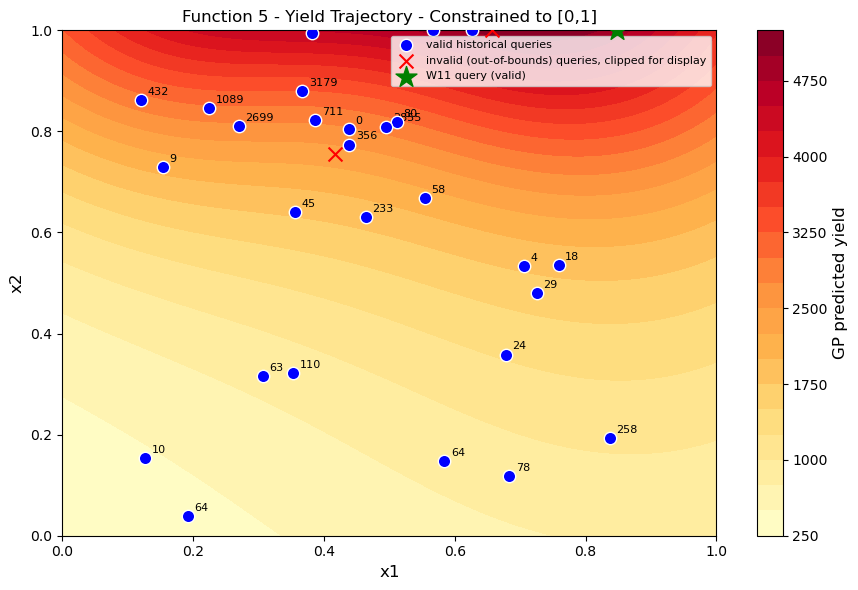

In [39]:
# --- GP vs SVR at historical VALID queries only ---
print("--- GP vs SVR at historical (valid) queries ---")
print(f"{'Point':<8} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(valid_inputs_F5, valid_outputs_F5)):
    gp_pred  = np.expm1(gp_F5.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr_F5.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"{i:<8} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")

# --- Plot: contour restricted to the VALID [0,1] search space only ---
grid_n = 80
x1_range = np.linspace(0.0, 1.0, grid_n)
x2_range = np.linspace(0.0, 1.0, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp_F5.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

# valid historical points in blue
ax.scatter(valid_inputs_F5[:, 0], valid_inputs_F5[:, 1], c='blue',
           edgecolors='white', s=80, zorder=5, label='valid historical queries')
for i in range(len(valid_inputs_F5)):
    ax.annotate(f'{valid_outputs_F5[i]:.0f}',
                (valid_inputs_F5[i, 0] + 0.01, valid_inputs_F5[i, 1] + 0.01), fontsize=8)

# invalid (out-of-bounds) historical points shown in red, clipped to the boundary for display only
clipped_invalid = np.clip(all_inputs_F5[oob_mask], 0.0, 1.0)
if len(clipped_invalid):
    ax.scatter(clipped_invalid[:, 0], clipped_invalid[:, 1], c='red', marker='x', s=100,
               zorder=6, label='invalid (out-of-bounds) queries, clipped for display')

ax.scatter(query_F5[0], query_F5[1], marker='*', c='green', s=250, zorder=10, label='W11 query (valid)')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory - Constrained to [0,1]')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

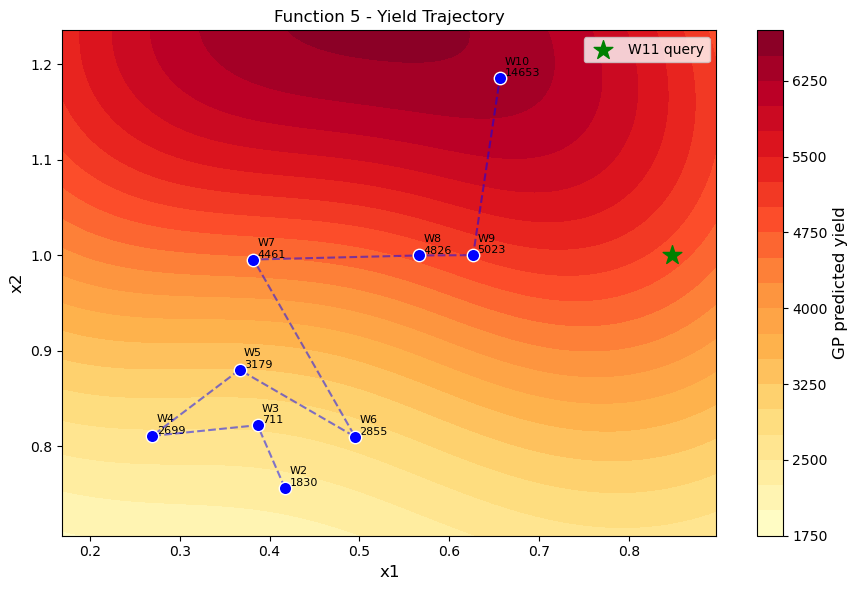

In [40]:
# Plot a 2D contour (x1 vs x2, with x3/x4 held near 1) of the GP's predicted yield,
#  overlaying the historical query trajectory and the UCB-selected W10 query 
#  to visualise the search path as it moves beyond the original [0,1] bounds.

pad = 0.05
x1_min = min(prev_queries_F5[:, 0].min(), query_F5[0]) - 0.1
x1_max = max(prev_queries_F5[:, 0].max(), query_F5[0]) + pad
x2_min = min(prev_queries_F5[:, 1].min(), query_F5[1]) - pad
x2_max = max(prev_queries_F5[:, 1].max(), query_F5[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp_F5.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries_F5)):
    ax.scatter(prev_queries_F5[i, 0], prev_queries_F5[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+2}\n{prev_outputs_F5[i]:.0f}',   # no data for W1
                (prev_queries_F5[i, 0] + 0.005, prev_queries_F5[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries_F5[:, 0], prev_queries_F5[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query_F5[0], query_F5[1], marker='*', c='green', s=200, zorder=10, label='W11 query')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory')
ax.legend()
fig.tight_layout()
plt.show()

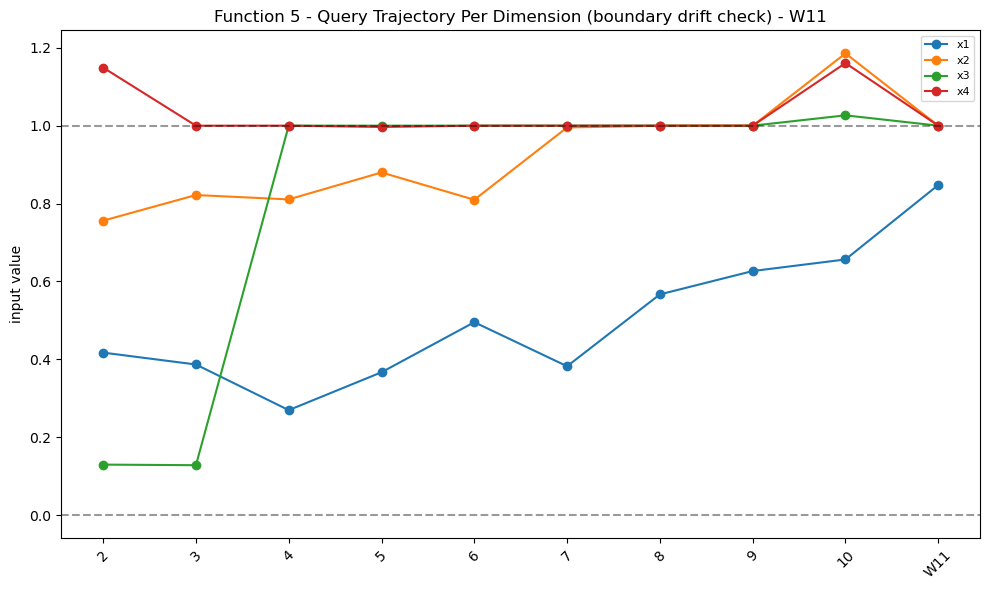

In [41]:
# --- Alternative Visualization: per-dimension query trajectory across weeks ---
dim_names_f5_alt = ['x1', 'x2', 'x3', 'x4']
history_f5_alt = np.vstack([prev_queries_F5, query_F5])
weeks_f5_alt = list(range(2, 2 + len(prev_queries_F5))) + ['W11']

fig, ax = plt.subplots(figsize=(10, 6))
for d in range(4):
    ax.plot(range(len(history_f5_alt)), history_f5_alt[:, d], marker='o', label=dim_names_f5_alt[d])

ax.axhline(0, color='black', linestyle='--', alpha=0.4)
ax.axhline(1, color='black', linestyle='--', alpha=0.4)
ax.set_xticks(range(len(history_f5_alt)))
ax.set_xticklabels(weeks_f5_alt, rotation=45)
ax.set_ylabel('input value')
ax.set_title('Function 5 - Query Trajectory Per Dimension (boundary drift check) - W11')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Function 6 A cake recipe, 5D array, 20 original samples - Week 11

In [42]:
# =============================================================================
# Function 6 A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)
# W5: RF surrogate (200 trees); acquisition via Thompson sampling 
#     using a single randomly selected decision tree rather than the ensemble mean
# W6: Random Forest (500 trees); Maximin LHS candidate design; Full-ensemble UCB
# W7: Random Forest Max depth = 5 (new); UCB κ = 1.5; the first explicit regularisation of the RF model
# W8: Hybrid GP + RF (inverse-RMSE weighted blend) + EI with multi-restart L-BFGS-B optimization
# W9: Random Forest surrogate with SHAP explainability; Feature importance explanations influence future search direction
# W10: Two-stage LHS (global + local refinement) scored by GP (isotropic Matérn) + UCB (κ = 2.5); SVR fit but not used for acquisition.

# changes: Demote SVR to interpretability analysis after detecting high overfitting gaps
#          return to an ARD GP for two-stage LHS candidate scoring.

print("\n" + "=" * 60)
print("Function 6 - Week 11")
print("=" * 60)

f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],              # W2
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],              # W3 
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],              # W4
    [0.611853, 0.139494, 0.292145, 0.366362, 0.456070],              # W5
    [0.362372, 0.287752, 0.659391, 0.946547, 0.011897],              # W6 
    [0.119239, 0.206322, 0.998767, 0.816254, 0.063518],              # W7 
    [0.471908, 0.343816, 1.000000, 0.988610, 0.154640],              # W8 
    [0.471060, 0.378037, 0.568185, 0.870856, 0.026973],              # W9 
    [0.317166, 0.547049, 0.105786, 1.000000, 0.002390],              # W10
])
prev_outputs_F6 = np.array([-1.241946,         # W2 (fail)
                            -0.352945,         # W3 (above initial best)
                            -0.837300,         # W4 (fail)
                            -1.468430,         # W5 (fail)
                            -0.454581,         # W6 (above initial best)
                            -0.859304,         # W7 (fail)
                            -0.650775,         # W8 (above initial best)
                            -0.338381,         # W9 (above initial best, so far the best)
                            -1.088831,         # W10 (fail)
                           ])

all_inputs_F6  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

print(f"Total observations: {all_inputs_F6.shape[0]}, best (max): {all_outputs_F6.max():.4f}")


Function 6 - Week 11
Total observations: 29, best (max): -0.3384


In [43]:
# --- SVR surrogate (kept ONLY for SHAP interpretability, as in W10) ---
svr_F6 = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=50, gamma=0.1, epsilon=0.001))])
svr_F6.fit(all_inputs_F6, all_outputs_F6)

# Diagnostic: is the SVR fit trustworthy enough to drive acquisition on its own?
svr_train_preds = svr_F6.predict(all_inputs_F6)
svr_train_mae   = mean_absolute_error(all_outputs_F6, svr_train_preds)
svr_loo_preds   = cross_val_predict(svr_F6, all_inputs_F6, all_outputs_F6, cv=LeaveOneOut())
svr_loo_mae     = mean_absolute_error(all_outputs_F6, svr_loo_preds)

print(f"SVR train MAE: {svr_train_mae:.4f}   SVR LOO-CV MAE: {svr_loo_mae:.4f}"
      f"  (ratio {svr_loo_mae / svr_train_mae:.0f}x)")
print("-> Large gap = the tight hyperparameters (C=50, epsilon=0.001) let the SVR")
print("   memorise the 29 training points instead of generalising. Its predicted mean")
print("   also carries no uncertainty estimate, so ranking candidates by raw SVR output")
print("   (as the W11 draft did) is pure exploitation of a surrogate that is known to")
print("   overfit - the same failure mode behind several earlier weeks' misses.")
print("   -> Keeping SVR for SHAP only, and using a GP (with predictive std) for the")
print("      actual UCB acquisition, as in the successful W6/W8/W10 approaches.")

# --- GP surrogate (mean + std) used for acquisition, as in W10 ---
gp_kernel = ConstantKernel(1.0) * Matern(length_scale=np.ones(5), length_scale_bounds=(1e-2, 1e2), nu=2.5) \
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1))
gp_F6 = GaussianProcessRegressor(kernel=gp_kernel, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp_F6.fit(all_inputs_F6, all_outputs_F6)

gp_loo_preds = cross_val_predict(gp_F6, all_inputs_F6, all_outputs_F6, cv=LeaveOneOut())
gp_loo_mae   = mean_absolute_error(all_outputs_F6, gp_loo_preds)
print(f"\nGP LOO-CV MAE: {gp_loo_mae:.4f} (comparable generalisation, but GP also gives a")
print("calibrated sigma per point, which the SVR cannot provide)")

# --- Two-stage candidate refinement (unchanged design from W10/W11 draft) ---
space = Space([(0.0, 1.0)] * 5)
lhs   = Lhs(criterion="maximin", iterations=100)

# Stage 1: global LHS, scored by GP + UCB
np.random.seed(42)
stage1 = np.array(lhs.generate(space.dimensions, 5000))
mu1, sigma1 = gp_F6.predict(stage1, return_std=True)
ucb1 = compute_ucb(mu1, sigma1, kappa=2.5)

# Stage 2: local refinement around top-K UCB anchors from stage 1
top_k = 50
top_k_idx = np.argsort(ucb1)[-top_k:]
top_k_points = stage1[top_k_idx]

radius = 0.05
stage2 = []
for point in top_k_points:
    local = point + np.random.uniform(-radius, radius, size=(100, 5))
    local = np.clip(local, 0, 1)
    stage2.append(local)
stage2 = np.vstack(stage2)


SVR train MAE: 0.0011   SVR LOO-CV MAE: 0.1924  (ratio 171x)
-> Large gap = the tight hyperparameters (C=50, epsilon=0.001) let the SVR
   memorise the 29 training points instead of generalising. Its predicted mean
   also carries no uncertainty estimate, so ranking candidates by raw SVR output
   (as the W11 draft did) is pure exploitation of a surrogate that is known to
   overfit - the same failure mode behind several earlier weeks' misses.
   -> Keeping SVR for SHAP only, and using a GP (with predictive std) for the
      actual UCB acquisition, as in the successful W6/W8/W10 approaches.

GP LOO-CV MAE: 0.2125 (comparable generalisation, but GP also gives a
calibrated sigma per point, which the SVR cannot provide)


In [44]:
# Combine and score using GP + UCB (kappa = 2.5), consistent with the successful W6/W10 acquisitions
all_candidates = np.vstack([stage1, stage2])
mu_all, sigma_all = gp_F6.predict(all_candidates, return_std=True)
ucb_all = compute_ucb(mu_all, sigma_all, kappa=2.5)

best_index_F6 = np.argmax(ucb_all)
query_F6 = all_candidates[best_index_F6]

# For context only (not used to choose the query): what would the (overfit) SVR have predicted here?
svr_pred_at_query = svr_F6.predict(query_F6.reshape(1, -1))[0]

# Report source
source = "Stage 1 (global)" if best_index_F6 < len(stage1) else "Stage 2 (refined)"

print(f"\nStage 1: {len(stage1)} global candidates")
print(f"Stage 2: {len(stage2)} local candidates ({top_k} anchors x 100 each, radius={radius})")
print(f"Total:   {len(all_candidates)} candidates")

print(f"\nWeek 11 Query (GP+UCB): {format_query(query_F6)}")
print(f"  GP mean (mu):      {mu_all[best_index_F6]:.4f}")
print(f"  GP std (sigma):    {sigma_all[best_index_F6]:.4f}")
print(f"  UCB score:         {ucb_all[best_index_F6]:.4f}")
print(f"  SVR prediction here (for comparison only): {svr_pred_at_query:.4f}")
print(f"  Source: {source}")

nearest_dist = cdist(query_F6.reshape(1, -1), all_inputs_F6).min()
print(f"  Distance to nearest observed point: {nearest_dist:.4f}")
print(f"\nCurrent best observed (max): {f_best if (f_best := all_outputs_F6.max()) else all_outputs_F6.max():.4f} "
      f"(target to beat/keep above initial max of {f6_outputs.max():.4f})")


Stage 1: 5000 global candidates
Stage 2: 5000 local candidates (50 anchors x 100 each, radius=0.05)
Total:   10000 candidates

Week 11 Query (GP+UCB): 0.377923-0.149075-0.975196-0.121707-0.000000
  GP mean (mu):      -0.9726
  GP std (sigma):    0.3282
  UCB score:         -0.1521
  SVR prediction here (for comparison only): -1.1224
  Source: Stage 2 (refined)
  Distance to nearest observed point: 0.7157

Current best observed (max): -0.3384 (target to beat/keep above initial max of -0.7143)


  0%|          | 0/29 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_15684\1351558821.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs_F6,


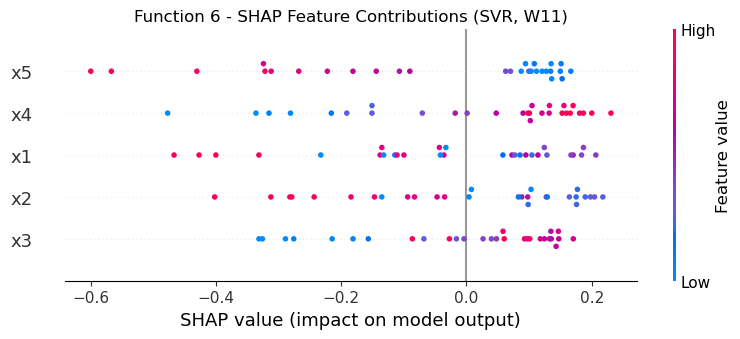

In [45]:
# --- Interpretability: SHAP on SVR (actual surrogate) ---
np.random.seed(42)
background  = all_inputs_F6[np.random.choice(len(all_inputs_F6), size=20, replace=False)]
explainer   = shap.KernelExplainer(svr_F6.predict, background)
shap_values = explainer.shap_values(all_inputs_F6, nsamples=100)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs_F6,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions (SVR, W11)')
plt.tight_layout()
plt.show()

  0%|          | 0/29 [00:00<?, ?it/s]

<Figure size 800x500 with 0 Axes>

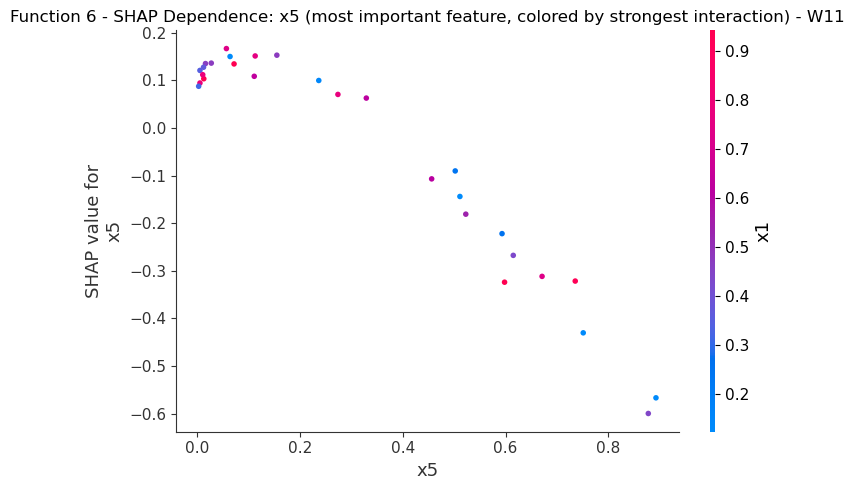

In [46]:
# --- Alternative Visualization: SHAP dependence plot for the top feature ---
np.random.seed(42)
background_f6_alt = all_inputs_F6[np.random.choice(len(all_inputs_F6), size=min(20, len(all_inputs_F6)), replace=False)]
explainer_f6_alt  = shap.KernelExplainer(svr_F6.predict, background_f6_alt)
shap_values_f6_alt = explainer_f6_alt.shap_values(all_inputs_F6, nsamples=100)

sv_f6_alt = shap_values_f6_alt[0] if isinstance(shap_values_f6_alt, list) else shap_values_f6_alt
sv_f6_alt = np.asarray(sv_f6_alt)

assert sv_f6_alt.shape[0] == all_inputs_F6.shape[0], \
    f"Row mismatch: shap_values has {sv_f6_alt.shape[0]} rows, all_inputs_F6 has {all_inputs_F6.shape[0]}"

mean_abs_shap_f6_alt = np.abs(sv_f6_alt).mean(axis=0)
top_feat_idx_f6_alt = int(np.argmax(mean_abs_shap_f6_alt))
feature_names_f6_alt = [f'x{i+1}' for i in range(5)]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feat_idx_f6_alt, sv_f6_alt, all_inputs_F6,
                      feature_names=feature_names_f6_alt, show=False)
plt.title(f'Function 6 - SHAP Dependence: {feature_names_f6_alt[top_feat_idx_f6_alt]} '
          f'(most important feature, colored by strongest interaction) - W11')
plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples - Week 11

In [47]:
# =============================================================================
# Function 7, Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)
# W5: Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, 
#     then RF re-ranks the top 1,000 candidates
# W6: RF (importance) → ARD GP; Importance-driven subspace narrowing; UCB, multi-start L-BFGS-B
# W7: Two Random Forests → subspace → GP + UCB; Subspace bounds; UCB κ = 2
#     RF-based filtering isolated the dominant HP1 region before GP optimisation
# W8: Two-stage RF filtering (full RF → filtered RF) → GP + UCB (κ = 1.5)
# W9: Dataset filtering before Random Forest optimisation; Reshaping the optimisation landscape through adaptive data selection
# W10: Two-stage RF filtering (100k → 10k → 1k) → GP (sqrt(Y), Matérn + DotProduct) with custom EI computed on the original output scale.

# changes: Replace failing multi-stage Random Forest filtering with continuous trust-region optimisation 
#          use a Matérn plus DotProduct kernel on square-root targets.

print("\n" + "=" * 60)
print("Function 7 - Week 11")
print("=" * 60)

f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],    # W2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],    # W3
    [0.012357, 0.162903, 0.399853, 0.082758, 0.249752, 0.923732],    # W4
    [0.042283, 0.348468, 0.793617, 0.259525, 0.456849, 0.822122],    # W5
    [0.020000, 0.084621, 0.685565, 0.148317, 0.347709, 0.669559],    # W6
    [0.063339, 0.123643, 0.074385, 0.373415, 0.318790, 0.765081],    # W7
    [0.002711, 0.256031, 0.238702, 0.111803, 0.341715, 0.769368],    # W8
    [0.057264, 0.054996, 0.341841, 0.256882, 0.307001, 0.720016],    # W9
    [0.059517, 0.056546, 0.864985, 0.258438, 0.352116, 0.678089],    # W10
])
prev_outputs_F7 = np.array([0.59279,                  # W2 (fail)
                            2.59480,                  # W3 (above initial max)
                            1.08804,                  # W4 (fail)
                            1.31103,                  # W5 (fail)
                            2.130313,                 # W6 (above initial max)
                            2.06359,                  # W7 (above initial max)
                            1.642928,                 # W8 (above initial max)
                            2.74921,                  # W9 (above initial max, so far the best)
                            1.76236,                  # W10 (above initial max, but well below the record)
                           ])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])

best_idx_w10 = np.argmax(all_outputs_F7)
print(f'Number of observations: {len(all_outputs_F7)}')
print(f'Observed best output: {all_outputs_F7[best_idx_w10]:.6f}')
print('Observed best query:', all_inputs_F7[best_idx_w10])


Function 7 - Week 11
Number of observations: 39
Observed best output: 2.749210
Observed best query: [0.057264 0.054996 0.341841 0.256882 0.307001 0.720016]


In [48]:
feature_names = [f"HP{i+1}" for i in range(6)]

# --- Step 1a: Full-dataset Random Forest
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs_F7, all_outputs_F7)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")

# --- Step 1b: Filtered RF (HP1 < threshold subset) - RETAINED FOR DIAGNOSTIC/COMPARISON ONLY
hp1_threshold = 0.1
print(f"\nStep 1b: Filtered Random Forest + SHAP (HP1 < {hp1_threshold} subset)")
hp1_mask = all_inputs_F7[:, 0] < hp1_threshold
filtered_inputs  = all_inputs_F7[hp1_mask]
filtered_outputs = all_outputs_F7[hp1_mask]

print(f"Points with HP1 < {hp1_threshold}: {hp1_mask.sum()}  <-- very small sample to fit a 6D RF on")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")


Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.841
  HP2: 0.051
  HP3: 0.017
  HP4: 0.020
  HP5: 0.032
  HP6: 0.039

Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 13  <-- very small sample to fit a 6D RF on
Output range in subset: 0.008 to 2.749

Filtered RF importance:
  HP1: 0.366  (was 0.841 in full dataset) ***
  HP2: 0.218  (was 0.051 in full dataset) ***
  HP3: 0.035  (was 0.017 in full dataset) 
  HP4: 0.091  (was 0.020 in full dataset) 
  HP5: 0.072  (was 0.032 in full dataset) 
  HP6: 0.218  (was 0.039 in full dataset) ***


In [49]:
# Permutation importance validation (both RFs)

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs_F7, all_outputs_F7,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1, n=13):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")

# SHAP on filtered RF (diagnostic)
explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")


Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.841        1.619      0.264
  HP2           0.051        0.052      0.019
  HP3           0.017        0.009      0.002
  HP4           0.020        0.017      0.005
  HP5           0.032        0.026      0.007
  HP6           0.039        0.045      0.016

Permutation vs impurity importance (filtered HP1 < 0.1, n=13):
  Feature    Impurity  Permutation   Perm std
  HP1           0.366        0.473      0.189
  HP2           0.218        0.194      0.082
  HP3           0.035        0.017      0.005
  HP4           0.091        0.036      0.011
  HP5           0.072        0.043      0.017
  HP6           0.218        0.178      0.074

SHAP analysis (filtered RF, diagnostic):
  Feature    |SHAP|  Mean SHAP
  HP1         0.294     +0.027
  HP2         0.160     -0.021
  HP3         0.020     -0.001
  HP4         0.038     +0.013
  HP5         0.053     +0.025
  HP6       

In [50]:
print("\nAUDIT: Week-10-style two-stage RF filtering + discrete GP-EI")

np.random.seed(42)
n_initial = 100000
candidates_F7 = np.random.uniform(0, 1, size=(n_initial, 6))

full_preds = rf_full.predict(candidates_F7)
top10k_idx = np.argsort(full_preds)[-10000:]
stage1 = candidates_F7[top10k_idx]

filt_preds = rf_filtered.predict(stage1)
top1k_idx = np.argsort(filt_preds)[-1000:]
stage2 = stage1[top1k_idx]

kernel_F7 = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
) + ConstantKernel(0.1, (0.01, 5.0)) * DotProduct(sigma_0=0.1, sigma_0_bounds=(0.01, 1.0))

gp_F7 = GaussianProcessRegressor(
    kernel=kernel_F7,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp_F7.fit(all_inputs_F7, np.sqrt(all_outputs_F7))

mu_F7, sigma_F7 = gp_F7.predict(stage2, return_std=True)
best_so_far_F7 = np.sqrt(all_outputs_F7.max())
xi_F7 = 0.01
z_F7 = (mu_F7 - best_so_far_F7 - xi_F7) / (sigma_F7 + 1e-10)
ei_F7 = (mu_F7 - best_so_far_F7 - xi_F7) * norm.cdf(z_F7) + sigma_F7 * norm.pdf(z_F7)
ei_F7[sigma_F7 < 1e-10] = 0.0

old_best_idx = np.argmax(ei_F7)
old_candidate = stage2[old_best_idx]
old_mean, old_std = gp_F7.predict(old_candidate.reshape(1, -1), return_std=True)
old_predicted_y = old_mean[0] ** 2

print(f"Candidate this recipe would propose : {format_query(old_candidate)}")
print(f"GP predicted Y (original scale)      : {old_predicted_y:.4f}")
print(f"EI score (sqrt scale)                : {ei_F7[old_best_idx]:.6f}")
print(f"Current record to beat               : {all_outputs_F7.max():.4f}")

print("\n*** VERDICT ***")
if old_predicted_y < all_outputs_F7.max():
    print("FAIL: the GP's own prediction for this candidate (%.4f) is BELOW the current record (%.4f)."
          % (old_predicted_y, all_outputs_F7.max()))
    print("Combined with a near-zero EI (%.6f), the model has essentially no expectation of improvement." % ei_F7[old_best_idx])
    print("This matches what actually happened at Week 10 (1.76236, a big drop from the 2.74921 record).")
    print("Root cause: rf_filtered is trained on only 13 points, so Stage-2 filtering is unreliable and")
    print("collapses the 1,000-candidate pool into a region the GP does not rate as promising.")


AUDIT: Week-10-style two-stage RF filtering + discrete GP-EI
Candidate this recipe would propose : 0.057146-0.038834-0.320530-0.305527-0.377308-0.643734
GP predicted Y (original scale)      : 2.5368
EI score (sqrt scale)                : 0.010694
Current record to beat               : 2.7492

*** VERDICT ***
FAIL: the GP's own prediction for this candidate (2.5368) is BELOW the current record (2.7492).
Combined with a near-zero EI (0.010694), the model has essentially no expectation of improvement.
This matches what actually happened at Week 10 (1.76236, a big drop from the 2.74921 record).
Root cause: rf_filtered is trained on only 13 points, so Stage-2 filtering is unreliable and
collapses the 1,000-candidate pool into a region the GP does not rate as promising.


In [51]:
print("\nFIX: adaptive top-K trust region + continuous multi-start EI optimisation")

K = 8  # top ~20% of 39 observations
top_idx = np.argsort(all_outputs_F7)[-K:]
top_pts = all_inputs_F7[top_idx]

lo = top_pts.min(axis=0)
hi = top_pts.max(axis=0)
margin = 0.15 * (hi - lo + 1e-6)
lo_b = np.clip(lo - margin, 0, 1)
hi_b = np.clip(hi + margin, 0, 1)

print(f"Trust region built from the top {K} observed points:")
for name, l, h in zip(feature_names, lo_b, hi_b):
    print(f"  {name}: [{l:.3f}, {h:.3f}]")

best_so_far_F7 = np.sqrt(all_outputs_F7.max())
xi_F7 = 0.01

def neg_ei(x):
    x = np.clip(x, 0, 1).reshape(1, -1)
    mu, sigma = gp_F7.predict(x, return_std=True)
    sigma = max(sigma[0], 1e-9)
    z = (mu[0] - best_so_far_F7 - xi_F7) / sigma
    ei = (mu[0] - best_so_far_F7 - xi_F7) * norm.cdf(z) + sigma * norm.pdf(z)
    return -ei

bounds = list(zip(lo_b, hi_b))
rng = np.random.default_rng(42)
starts = rng.uniform(lo_b, hi_b, size=(300, 6))

best_val, best_x = np.inf, None
for s in starts:
    res = minimize(neg_ei, s, bounds=bounds, method='L-BFGS-B')
    if res.fun < best_val:
        best_val, best_x = res.fun, res.x

new_mean, new_std = gp_F7.predict(best_x.reshape(1, -1), return_std=True)
new_predicted_y = new_mean[0] ** 2
new_ei = -best_val

query_F7 = best_x

print(f"\nWeek 11 Query                    : {format_query(query_F7)}")
print(f"GP predicted Y (original scale)  : {new_predicted_y:.4f}")
print(f"GP uncertainty (sqrt scale std)  : {new_std[0]:.4f}")
print(f"EI score (sqrt scale)            : {new_ei:.6f}")
print(f"Distance to current best point   : {np.linalg.norm(query_F7 - all_inputs_F7[best_idx_w10]):.4f}")


FIX: adaptive top-K trust region + continuous multi-start EI optimisation
Trust region built from the top 8 observed points:
  HP1: [0.000, 0.072]
  HP2: [0.000, 0.557]
  HP3: [0.000, 0.984]
  HP4: [0.073, 0.413]
  HP5: [0.285, 0.479]
  HP6: [0.647, 0.845]

Week 11 Query                    : 0.000000-0.058944-0.407235-0.285037-0.339090-0.712563
GP predicted Y (original scale)  : 2.9083
GP uncertainty (sqrt scale std)  : 0.0352
EI score (sqrt scale)            : 0.039899
Distance to current best point   : 0.0972


In [52]:
print("\n" + "=" * 60)
print("Old (two-stage RF) recipe  vs.  Fixed (trust region + continuous EI) recipe")
print("=" * 60)
print(f"{'':30}{'Old':>16}{'Fixed':>16}")
print(f"{'Predicted Y':30}{old_predicted_y:>16.4f}{new_predicted_y:>16.4f}")
print(f"{'EI (sqrt scale)':30}{ei_F7[old_best_idx]:>16.6f}{new_ei:>16.6f}")
print(f"{'Beats current record?':30}{str(old_predicted_y > all_outputs_F7.max()):>16}{str(new_predicted_y > all_outputs_F7.max()):>16}")

print("\nRecommended Week 11 query:")
print(f"  {format_query(query_F7)}")
print(f"  Predicted output: {new_predicted_y:.4f} (record to beat: {all_outputs_F7.max():.4f})")


Old (two-stage RF) recipe  vs.  Fixed (trust region + continuous EI) recipe
                                           Old           Fixed
Predicted Y                             2.5368          2.9083
EI (sqrt scale)                       0.010694        0.039899
Beats current record?                    False            True

Recommended Week 11 query:
  0.000000-0.058944-0.407235-0.285037-0.339090-0.712563
  Predicted output: 2.9083 (record to beat: 2.7492)


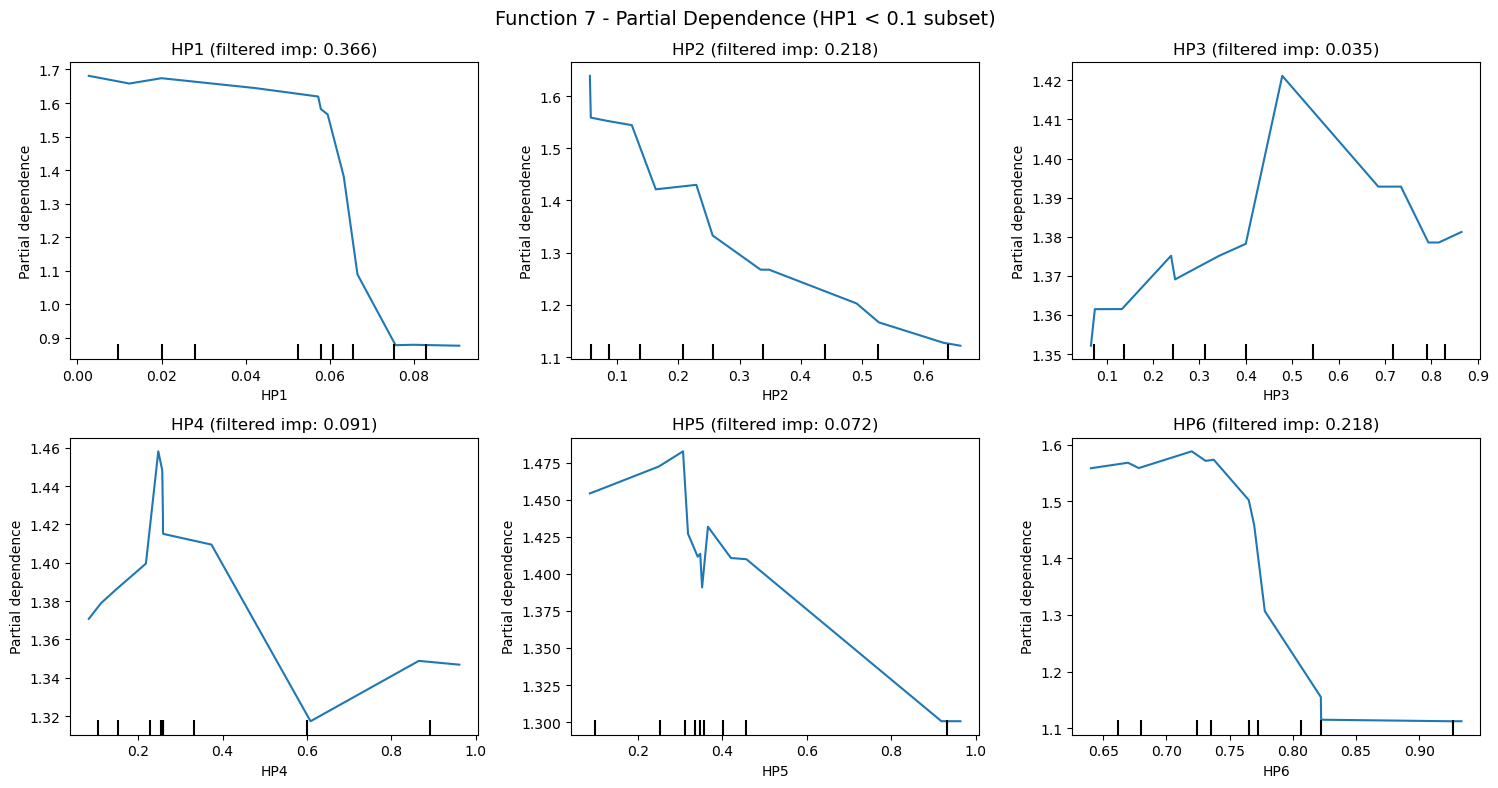

In [53]:
# --- Interpretability: Partial dependence on filtered RF ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

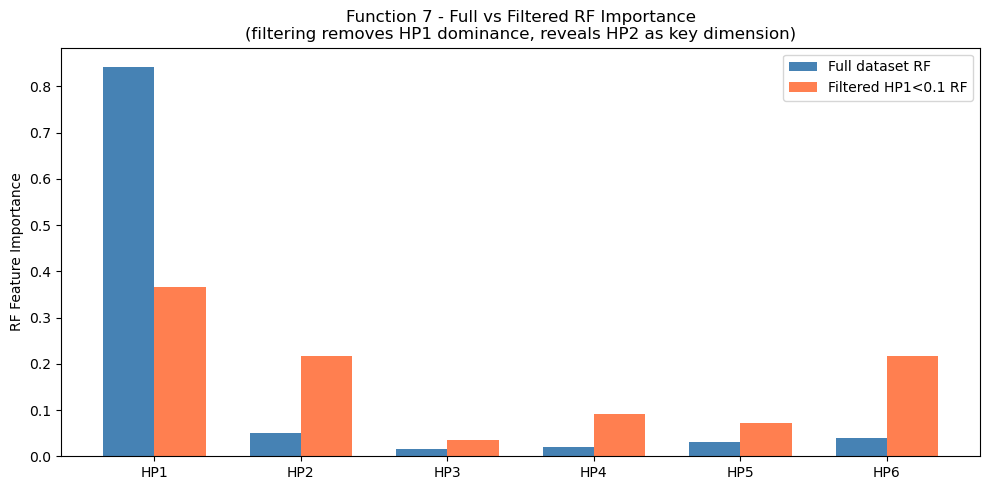

In [54]:
# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

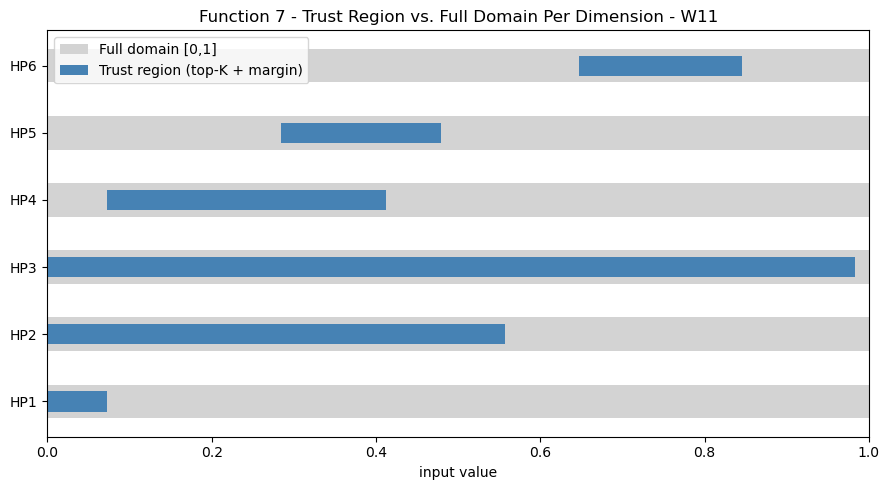

In [55]:
# --- Alternative Visualization: trust-region bounds vs full [0,1] domain ---
feature_names_f7_alt = [f"HP{i+1}" for i in range(6)]

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(6)

# full domain (light background bar)
ax.barh(y_pos, [1]*6, left=[0]*6, height=0.5, color='lightgrey', label='Full domain [0,1]')

# trust region
widths_f7_alt = hi_b - lo_b
ax.barh(y_pos, widths_f7_alt, left=lo_b, height=0.3, color='steelblue', label='Trust region (top-K + margin)')

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names_f7_alt)
ax.set_xlabel('input value')
ax.set_xlim(0, 1)
ax.set_title('Function 7 - Trust Region vs. Full Domain Per Dimension - W11')
ax.legend()
plt.tight_layout()
plt.show()

# Function 8, Unspecified field, 8D array, 40 original samples - Week 11

In [56]:
# =============================================================================
# Function 8, Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)
# W5: MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0)
# W6: Dropout MLP (8→24→24→1); Standard scaling; UCB via MC-dropout uncertainty
# W7: MC-Dropout MLP; Dropout = 0.2; hidden units = 24; UCB κ = 1.7; SHAP-scaled noise; 
#     HAP-informed candidate generation to guide exploration
# W8: MC-Dropout MLP + UCB with adaptive κ (κ_base × calibration ratio)
# W9: NN surrogate with MC dropout uncertainty; learned latent representations and stochastic uncertainty estimates
# W10: MC-Dropout MLP (weighted loss, increased capacity) + LHS candidate pool (50k) + UCB with adaptive κ (from LOO calibration).

# changes: Expand neural network capacity, raise dropout for better calibration
#          apply target-weighted loss to correct persistent under-predictions on high-scoring points.

print("\n" + "=" * 60)
print("Function 8 - Week 11")
print("=" * 60)

f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],     #W2
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],    #W3
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],    #W4
    [0.040725, 0.748531, 0.178080, 0.981020, 0.988831, 0.993927, 0.013038, 0.216952],    #W5
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],    #W6
    [0.000000, 0.009147, 0.046571, 0.113147, 0.150211, 0.340739, 0.038068, 0.928497],    #W7
    [0.007786, 0.000000, 0.000000, 0.000000, 0.999999, 0.368073, 0.022080, 0.018153],    #W8
    [0.000000, 0.000000, 0.001701, 0.357817, 0.997203, 0.357817, 0.357817, 0.002035],    #W9
    [0.071358, 0.056561, 0.038275, 0.129888, 0.740838, 0.572688, 0.045918, 0.708294],    #W10
])
prev_outputs_F8 = np.array([8.26488,                    #W2 (fail)
                            7.35099,                    #W3 (fail)
                            9.76008,                    #W4 (above initial max)
                            8.590830,                   #W5 (fail)
                            9.619999,                   #W6 (above initial max)
                            9.638210,                   #W7 (above initial max)
                            9.752723,                   #W8 (above initial max)
                            9.730200,                   #W9 (above initial max)
                            9.90829,                   #W10 (above initial max, so far the best)
                           ])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

print(f"Total points: {len(all_outputs_F8)}, best: {all_outputs_F8.max():.4f}")


Function 8 - Week 11
Total points: 49, best: 9.9083


In [57]:
# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs_F8)
Y_sc = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=24, dropout=0.25 (increased from 0.2 for better calibration)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

In [58]:
# LOO CV with dropout=0.25
loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs_F8)):
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

In [59]:
# Adaptive kappa: base * calibration ratio 
kappa_base = 1.7
cal_ratio  = loo_errors.mean() / loo_sigmas.mean()
kappa_F8      = kappa_base * cal_ratio

print(f"\nLOO Calibration (dropout=0.25):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio:.3f}  (1.0 = perfect calibration)")
print(f"  kappa (adaptive):    {kappa_F8:.2f}")


LOO Calibration (dropout=0.25):
  mean |error|:        0.2618
  std  |error|:        0.2660
  max  |error|:        1.2030
  mean sigma (LOO):    0.2184
  ratio (error/sigma): 1.199  (1.0 = perfect calibration)
  kappa (adaptive):    2.04


In [60]:
# --- Top-k LOO calibration analysis ---
top_k_threshold = 9.0
top_k_mask = all_outputs_F8 > top_k_threshold
top_k_indices = np.where(top_k_mask)[0]

top_k_errors = loo_errors[top_k_mask]
top_k_sigmas = loo_sigmas[top_k_mask]

top_k_cal_ratio = top_k_errors.mean() / top_k_sigmas.mean()

print(f"\nTop-k LOO Calibration (output > {top_k_threshold}):")
print(f"  n points:            {len(top_k_indices)}")
print(f"  mean |error|:        {top_k_errors.mean():.4f}")
print(f"  std  |error|:        {top_k_errors.std():.4f}")
print(f"  max  |error|:        {top_k_errors.max():.4f}")
print(f"  mean sigma:          {top_k_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_ratio:.3f}")
print(f"  global ratio was:    {cal_ratio:.3f}")


Top-k LOO Calibration (output > 9.0):
  n points:            11
  mean |error|:        0.1522
  std  |error|:        0.1762
  max  |error|:        0.6106
  mean sigma:          0.2311
  ratio (error/sigma): 0.659
  global ratio was:    1.199


In [61]:
# Per-point breakdown for the top-k
print(f"\n  Per-point breakdown (top-k):")
for idx in top_k_indices:
    print(f"    point {idx:2d}: y={all_outputs_F8[idx]:.4f}, "
          f"|err|={loo_errors[idx]:.4f}, sigma={loo_sigmas[idx]:.4f}, "
          f"ratio={loo_errors[idx]/loo_sigmas[idx]:.3f}")

# --- High-error initial points: where are they? ---
high_error_initial = [14, 22, 26, 39]
print("\nHigh-error initial points (output > 9.0):")
for idx in high_error_initial:
    print(f"  point {idx}: {np.array2string(all_inputs_F8[idx], precision=3, suppress_small=True)}"
          f"  y={all_outputs_F8[idx]:.4f}  |err|={loo_errors[idx]:.4f}")

# Compare to best query (W10)
print(f"\n  W10 (best): {np.array2string(all_inputs_F8[47], precision=3, suppress_small=True)}"
      f"  y={all_outputs_F8[47]:.4f}")


  Per-point breakdown (top-k):
    point 14: y=9.5985, |err|=0.0558, sigma=0.2386, ratio=0.234
    point 19: y=9.0131, |err|=0.2005, sigma=0.1799, ratio=1.114
    point 22: y=9.1416, |err|=0.3733, sigma=0.1254, ratio=2.978
    point 26: y=9.3443, |err|=0.6106, sigma=0.1393, ratio=4.382
    point 39: y=9.1830, |err|=0.0716, sigma=0.1960, ratio=0.366
    point 42: y=9.7601, |err|=0.0208, sigma=0.2738, ratio=0.076
    point 44: y=9.6200, |err|=0.0550, sigma=0.2913, ratio=0.189
    point 45: y=9.6382, |err|=0.0050, sigma=0.2892, ratio=0.017
    point 46: y=9.7527, |err|=0.0349, sigma=0.2845, ratio=0.123
    point 47: y=9.7302, |err|=0.1080, sigma=0.2452, ratio=0.440
    point 48: y=9.9083, |err|=0.1385, sigma=0.2784, ratio=0.497

High-error initial points (output > 9.0):
  point 14: [0.056 0.066 0.023 0.039 0.404 0.801 0.488 0.893]  y=9.5985  |err|=0.0558
  point 22: [0.145 0.119 0.421 0.388 0.155 0.875 0.511 0.729]  y=9.1416  |err|=0.3733
  point 26: [0.193 0.631 0.417 0.491 0.796 0.655 

In [62]:
# --- train final model (weighted loss, increased capacity) ---
# Weight: high-scoring points matter more
weights = np.ones(len(all_outputs_F8))
weights[all_outputs_F8 > 9.0] = 5.0
weights[all_outputs_F8 > 9.5] = 10.0
weight_tensor = torch.tensor(weights, dtype=torch.float32)

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(1500):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = (weight_tensor * (pred.squeeze() - Y_tensor.squeeze())**2).mean()
    loss.backward()
    optimiser.step()

print(f"Training loss (final, weighted): {loss.item():.6f}")

Training loss (final, weighted): 0.086937


In [63]:
# --- Weighted LOO for comparison ---
loo_errors_w = []
loo_sigmas_w = []

for i in range(len(all_outputs_F8)):
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    w_loo = np.ones(len(y_train_loo))
    w_loo[y_train_loo > 9.0] = 5.0
    w_loo[y_train_loo > 9.5] = 10.0
    w_loo_tensor = torch.tensor(w_loo, dtype=torch.float32)

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1500):
        optimiser_loo.zero_grad()
        pred_loo = model_loo(X_tr_tensor)
        loss_loo = (w_loo_tensor * (pred_loo.squeeze() - Y_tr_tensor.squeeze())**2).mean()
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors_w.append(abs(mu_loo - y_test_loo))
    loo_sigmas_w.append(sigma_loo)

loo_errors_w = np.array(loo_errors_w)
loo_sigmas_w = np.array(loo_sigmas_w)

cal_ratio_w = loo_errors_w.mean() / loo_sigmas_w.mean()
kappa_w     = kappa_base * cal_ratio_w

print(f"\nWeighted LOO Calibration (hidden=48):")
print(f"  mean |error|:        {loo_errors_w.mean():.4f}")
print(f"  mean sigma:          {loo_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio_w:.3f}")
print(f"  kappa (adaptive):    {kappa_w:.2f}")


Weighted LOO Calibration (hidden=48):
  mean |error|:        0.2031
  mean sigma:          0.1997
  ratio (error/sigma): 1.017
  kappa (adaptive):    1.73


In [64]:
# Top-k breakdown (weighted model)
top_k_mask_w = all_outputs_F8 > 9.0
top_k_errors_w = loo_errors_w[top_k_mask_w]
top_k_sigmas_w = loo_sigmas_w[top_k_mask_w]
top_k_cal_w    = top_k_errors_w.mean() / top_k_sigmas_w.mean()

print(f"\nWeighted Top-k LOO (output > 9.0):")
print(f"  mean |error|:        {top_k_errors_w.mean():.4f}")
print(f"  mean sigma:          {top_k_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_w:.3f}")
print(f"  previous top-k ratio was: 0.683")

print(f"\n  Per-point breakdown (top-k, weighted):")
top_k_indices_w = np.where(top_k_mask_w)[0]
for idx in top_k_indices_w:
    print(f"    point {idx:2d}: y={all_outputs_F8[idx]:.4f}, "
          f"|err|={loo_errors_w[idx]:.4f}, sigma={loo_sigmas_w[idx]:.4f}, "
          f"ratio={loo_errors_w[idx]/loo_sigmas_w[idx]:.3f}")


Weighted Top-k LOO (output > 9.0):
  mean |error|:        0.1261
  mean sigma:          0.1547
  ratio (error/sigma): 0.815
  previous top-k ratio was: 0.683

  Per-point breakdown (top-k, weighted):
    point 14: y=9.5985, |err|=0.0301, sigma=0.1732, ratio=0.174
    point 19: y=9.0131, |err|=0.1603, sigma=0.1369, ratio=1.171
    point 22: y=9.1416, |err|=0.3095, sigma=0.1071, ratio=2.890
    point 26: y=9.3443, |err|=0.4914, sigma=0.1269, ratio=3.873
    point 39: y=9.1830, |err|=0.0397, sigma=0.1384, ratio=0.287
    point 42: y=9.7601, |err|=0.0623, sigma=0.1771, ratio=0.352
    point 44: y=9.6200, |err|=0.0098, sigma=0.1621, ratio=0.061
    point 45: y=9.6382, |err|=0.0676, sigma=0.1552, ratio=0.436
    point 46: y=9.7527, |err|=0.0159, sigma=0.1801, ratio=0.088
    point 47: y=9.7302, |err|=0.0434, sigma=0.1692, ratio=0.257
    point 48: y=9.9083, |err|=0.1568, sigma=0.1759, ratio=0.892


  0%|          | 0/49 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_15684\1404941226.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


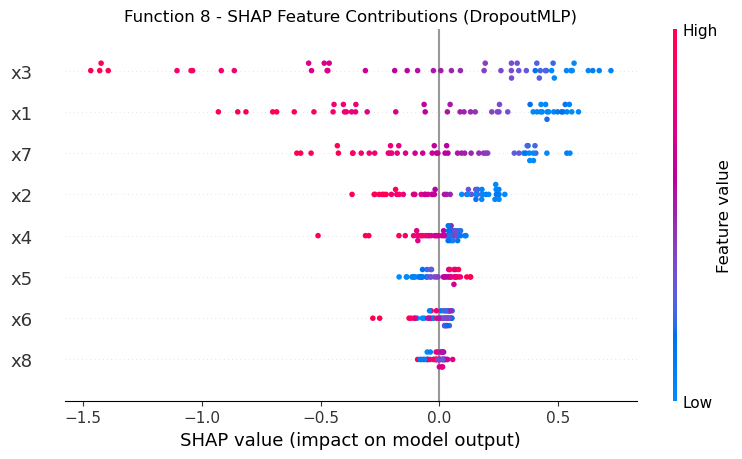

In [65]:
# --- SHAP on the DropoutMLP ---
model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP)')
plt.tight_layout()
plt.show()

In [66]:
model.train()  # back to train mode for MC dropout

# --- SHAP importance for noise scaling ---
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")

# ------ trying evenly spaced pool
sampler = LatinHypercube(d=8, seed=42)
pool = sampler.random(n=50000)

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=100)

mu_F8    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma_F8 = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb_F8      = mu_F8 + kappa_w * sigma_F8
best_idx_F8 = np.argmax(ucb_F8)
query_F8    = pool[best_idx_F8]

print(f"\nmu   range: {mu_F8.min():.3f} to {mu_F8.max():.3f}")
print(f"sigma range: {sigma_F8.min():.3f} to {sigma_F8.max():.3f}")
print(f"kappa*sigma range: {(kappa_F8*sigma_F8).min():.3f} to {(kappa_F8*sigma_F8).max():.3f}")

print(f"\nWeek 11 Query: {format_query(query_F8)}")
print(f"MC mu: {mu_F8[best_idx_F8]:.4f}, sigma: {sigma_F8[best_idx_F8]:.4f}")
print(f"UCB:   {ucb_F8[best_idx_F8]:.4f}")


SHAP-derived importance (normalised):
  x1: 0.759
  x2: 0.303
  x3: 1.000
  x4: 0.152
  x5: 0.129
  x6: 0.094
  x7: 0.501
  x8: 0.048

mu   range: 4.455 to 9.881
sigma range: 0.064 to 0.715
kappa*sigma range: 0.130 to 1.457

Week 11 Query: 0.092021-0.060978-0.018488-0.360040-0.924657-0.902361-0.221460-0.926437
MC mu: 9.8369, sigma: 0.2161
UCB:   10.2105


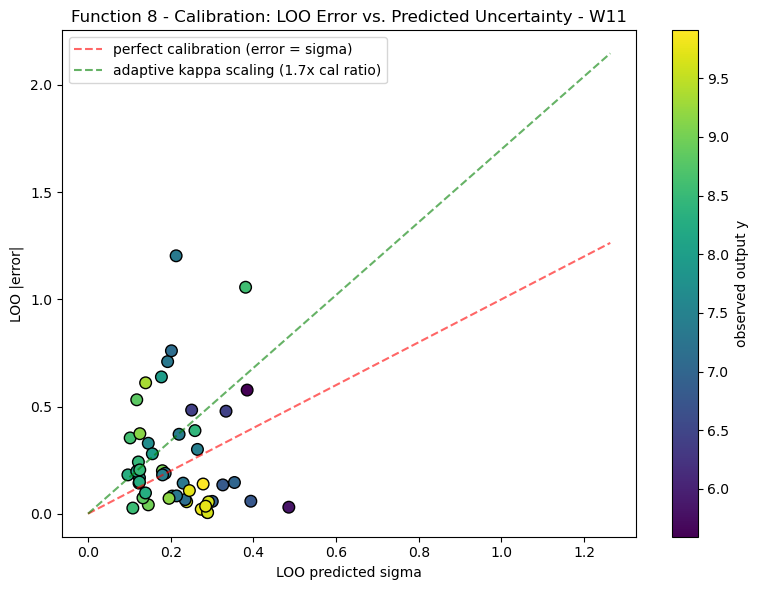

In [67]:
# --- Alternative Visualization: LOO calibration scatter ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(loo_sigmas, loo_errors, c=all_outputs_F8, cmap='viridis', s=70, edgecolors='black')
lims_f8_alt = [0, max(loo_sigmas.max(), loo_errors.max()) * 1.05]
ax.plot(lims_f8_alt, lims_f8_alt, 'r--', alpha=0.6, label='perfect calibration (error = sigma)')
ax.plot(lims_f8_alt, [kappa_base * l for l in lims_f8_alt], 'g--', alpha=0.6,
        label=f'adaptive kappa scaling ({kappa_base}x cal ratio)')
fig.colorbar(sc, ax=ax, label='observed output y')
ax.set_xlabel('LOO predicted sigma')
ax.set_ylabel('LOO |error|')
ax.set_title('Function 8 - Calibration: LOO Error vs. Predicted Uncertainty - W11')
ax.legend()
plt.tight_layout()
plt.show()

## Summary — this week's submissions

Collects the `query_F*` variable set in each section above, so the final submission list is read off one place rather than re-derived by eye from scattered print statements.

In [68]:
submissions = {
    1: query_F1,
    2: query_F2,
    3: query_F3,
    4: query_F4,
    5: query_F5,
    6: query_F6,
    7: query_F7,
    8: query_F8,
}

for fn_id, query in submissions.items():
    print(f"Function {fn_id}: {format_query(query)}")

Function 1: 0.396491-0.293437
Function 2: 0.697793-0.540885
Function 3: 0.395514-0.311838-0.461924
Function 4: 0.420876-0.518558-0.358976-0.385896
Function 5: 0.847572-1.000000-1.000000-1.000000
Function 6: 0.377923-0.149075-0.975196-0.121707-0.000000
Function 7: 0.000000-0.058944-0.407235-0.285037-0.339090-0.712563
Function 8: 0.092021-0.060978-0.018488-0.360040-0.924657-0.902361-0.221460-0.926437


# Fidelity Metrics: Surrogate vs Actual Black-Box Outputs

In [69]:
# Purpose:
#   Evaluate how closely the Week 11 surrogate predictions reproduced the
#   actual black-box outputs returned for the 8 submitted queries.
#
# IMPORTANT:
#   Function 1 uses the signed-score transformation in the notebook:
#
#       score = sign(y) * (300 + log10(abs(y) + eps))
#
#   The notebook reported:
#       mu (signed score) = 287.20
#
#   Since the predicted score is positive:
#
#       y_pred = 10 ** (score - 300)
#
# All other predictions below are taken from the Week 11 surrogate outputs
# reported in the notebook.
# =============================================================================

import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# Actual Week 11 black-box outputs supplied after the queries were evaluated
# -------------------------------------------------------------------------
actual_outputs = np.array([
    3.239181412509696e-13,    # Function 1
    0.6135463101527762,       # Function 2
    -0.01811187274510547,     # Function 3
    -1.3344156416018325,      # Function 4
    6469.995029080393,        # Function 5
    -1.3206459474653365,      # Function 6
    2.627029072209377,        # Function 7
    9.7292849417596            # Function 8
])

# -------------------------------------------------------------------------
# Week 11 surrogate predictions from the notebook
# -------------------------------------------------------------------------

# Function 1:
# Notebook prediction was on the signed-score scale:
f1_predicted_score = 287.20
f1_predicted_output = 10 ** (f1_predicted_score - 300)

# Functions 2-8:
predicted_outputs = np.array([
    f1_predicted_output,  # Function 1 - converted back to original scale
    0.603,                # Function 2 - GP mean
    -0.026100,            # Function 3 - predicted original-space output
    1.812,                # Function 4 - GP mean
    4865.48,              # Function 5 - GP predicted yield
    -0.9726,              # Function 6 - GP mean
    2.9083,               # Function 7 - predicted original-space Y
    9.8369                # Function 8 - MC-dropout mean
])

function_names = [f"Function {i}" for i in range(1, 9)]

# -------------------------------------------------------------------------
# Create comparison table
# -------------------------------------------------------------------------
fidelity_df = pd.DataFrame({
    "Function": function_names,
    "Actual": actual_outputs,
    "Predicted": predicted_outputs
})

fidelity_df["Error"] = fidelity_df["Predicted"] - fidelity_df["Actual"]
fidelity_df["Absolute Error"] = np.abs(fidelity_df["Error"])
fidelity_df["Squared Error"] = fidelity_df["Error"] ** 2

# Symmetric percentage error is preferable here because some actual values
# are negative and Function 1 is extremely close to zero.
fidelity_df["sMAPE (%)"] = (
    2 * fidelity_df["Absolute Error"] /
    (np.abs(fidelity_df["Actual"]) + np.abs(fidelity_df["Predicted"]) + 1e-300)
) * 100

# Relative error can become meaningless when the actual value is close to zero,
# so use it only where |actual| is sufficiently large.
relative_threshold = 1e-10

fidelity_df["Relative Error (%)"] = np.where(
    np.abs(fidelity_df["Actual"]) > relative_threshold,
    fidelity_df["Absolute Error"] / np.abs(fidelity_df["Actual"]) * 100,
    np.nan
)

# Display
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

print("Week 11 Surrogate vs Actual Black-Box Outputs")
display(fidelity_df)

Week 11 Surrogate vs Actual Black-Box Outputs


,Function,Actual,Predicted,Error,Absolute Error,Squared Error,sMAPE (%),Relative Error (%)
0,Function 1,3.23918e-13,1.58489e-13,-1.65429e-13,1.65429e-13,2.73667e-26,68.5847,NaN
1,Function 2,0.613546,0.603,-0.0105463,0.0105463,0.000111225,1.73381,1.71891
2,Function 3,-0.0181119,-0.0261,-0.00798813,0.00798813,6.38102e-05,36.1357,44.1044
3,Function 4,-1.33442,1.812,3.14642,3.14642,9.89993,200,235.79
4,Function 5,6470,4865.48,-1604.52,1604.52,2.57447e+06,28.3096,24.7993
5,Function 6,-1.32065,-0.9726,0.348046,0.348046,0.121136,30.354,26.3542
6,Function 7,2.62703,2.9083,0.281271,0.281271,0.0791133,10.1628,10.7068
7,Function 8,9.72928,9.8369,0.107615,0.107615,0.011581,1.10001,1.10609


In [70]:
# =============================================================================
# Overall Fidelity Metrics
# =============================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr, spearmanr

y_true = actual_outputs
y_pred = predicted_outputs

# -------------------------------------------------------------------------
# Standard regression fidelity metrics
# -------------------------------------------------------------------------

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# Pearson and Spearman correlation
pearson_r, pearson_p = pearsonr(y_true, y_pred)
spearman_r, spearman_p = spearmanr(y_true, y_pred)

# -------------------------------------------------------------------------
# Scale-normalised RMSE
# -------------------------------------------------------------------------
# Useful because Function 5 has a much larger output magnitude than the
# other functions.
actual_range = np.max(y_true) - np.min(y_true)
nrmse_range = rmse / actual_range

actual_std = np.std(y_true, ddof=1)
nrmse_std = rmse / actual_std

# -------------------------------------------------------------------------
# Mean symmetric absolute percentage error
# -------------------------------------------------------------------------

smape = np.mean(
    2 * np.abs(y_pred - y_true) /
    (np.abs(y_true) + np.abs(y_pred) + 1e-300)
) * 100

# -------------------------------------------------------------------------
# Print results
# -------------------------------------------------------------------------

metrics_df = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Pearson r",
        "Spearman ρ",
        "NRMSE (range)",
        "NRMSE (std)",
        "sMAPE (%)"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        pearson_r,
        spearman_r,
        nrmse_range,
        nrmse_std,
        smape
    ]
})

print("\n" + "=" * 70)
print("OVERALL SURROGATE FIDELITY")
print("=" * 70)

display(metrics_df)


OVERALL SURROGATE FIDELITY


,Metric,Value
0,MAE,201.052
1,RMSE,567.283
2,R²,0.929681
3,Pearson r,1
4,Spearman ρ,0.761905
5,NRMSE (range),0.0876609
6,NRMSE (std),0.24805
7,sMAPE (%),47.0476


In [71]:
# =============================================================================
# Per-function Fidelity Summary
# =============================================================================

summary_df = fidelity_df[
    [
        "Function",
        "Actual",
        "Predicted",
        "Error",
        "Absolute Error",
        "sMAPE (%)",
        "Relative Error (%)"
    ]
].copy()

print("=" * 90)
print("PER-FUNCTION SURROGATE FIDELITY")
print("=" * 90)

display(summary_df)

PER-FUNCTION SURROGATE FIDELITY


,Function,Actual,Predicted,Error,Absolute Error,sMAPE (%),Relative Error (%)
0,Function 1,3.23918e-13,1.58489e-13,-1.65429e-13,1.65429e-13,68.5847,NaN
1,Function 2,0.613546,0.603,-0.0105463,0.0105463,1.73381,1.71891
2,Function 3,-0.0181119,-0.0261,-0.00798813,0.00798813,36.1357,44.1044
3,Function 4,-1.33442,1.812,3.14642,3.14642,200,235.79
4,Function 5,6470,4865.48,-1604.52,1604.52,28.3096,24.7993
5,Function 6,-1.32065,-0.9726,0.348046,0.348046,30.354,26.3542
6,Function 7,2.62703,2.9083,0.281271,0.281271,10.1628,10.7068
7,Function 8,9.72928,9.8369,0.107615,0.107615,1.10001,1.10609


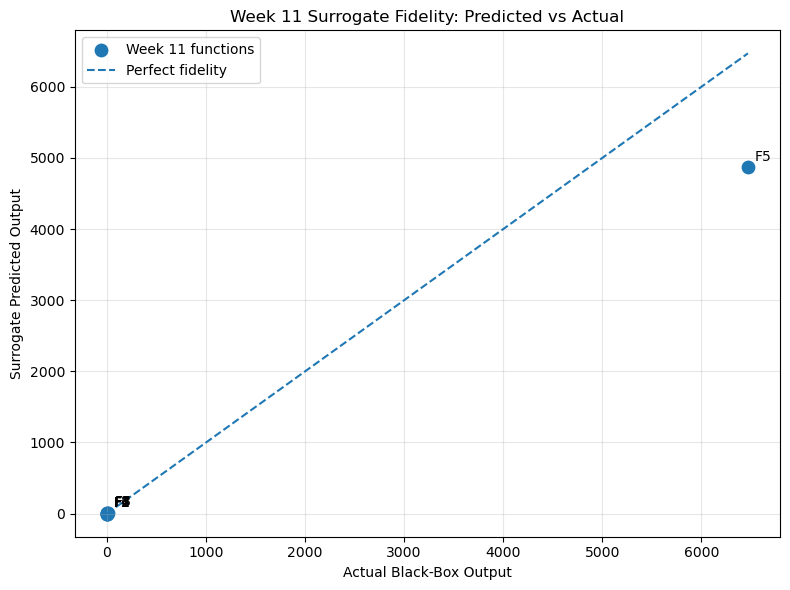

In [72]:
# =============================================================================
# Predicted vs Actual
# =============================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_true,
    y_pred,
    s=80,
    label="Week 11 functions"
)

# Perfect-prediction line
plot_min = min(y_true.min(), y_pred.min())
plot_max = max(y_true.max(), y_pred.max())

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    label="Perfect fidelity"
)

# Annotate functions
for i, name in enumerate(function_names):
    plt.annotate(
        name.replace("Function ", "F"),
        (y_true[i], y_pred[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Actual Black-Box Output")
plt.ylabel("Surrogate Predicted Output")
plt.title("Week 11 Surrogate Fidelity: Predicted vs Actual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# =============================================================================
# Normalised Per-Function Fidelity
# =============================================================================
#
# Raw MAE/RMSE is dominated by Function 5 because its output is ~6469.
# Therefore, calculate an error normalised by |actual| for each function.
#
# Function 1 is excluded from this percentage-based calculation because its
# actual output is approximately 3e-13, making percentage errors numerically
# unstable and scientifically misleading.
# =============================================================================

valid_mask = np.abs(y_true) > 1e-10

normalised_abs_error = np.full(len(y_true), np.nan)

normalised_abs_error[valid_mask] = (
    np.abs(y_pred[valid_mask] - y_true[valid_mask]) /
    np.abs(y_true[valid_mask])
)

normalised_df = pd.DataFrame({
    "Function": function_names,
    "Actual": y_true,
    "Predicted": y_pred,
    "Normalised Absolute Error": normalised_abs_error,
    "Accuracy (%)": np.where(
        valid_mask,
        (1 - normalised_abs_error) * 100,
        np.nan
    )
})

display(normalised_df)

,Function,Actual,Predicted,Normalised Absolute Error,Accuracy (%)
0,Function 1,3.23918e-13,1.58489e-13,NaN,NaN
1,Function 2,0.613546,0.603,0.0171891,98.2811
2,Function 3,-0.0181119,-0.0261,0.441044,55.8956
3,Function 4,-1.33442,1.812,2.3579,-135.79
4,Function 5,6470,4865.48,0.247993,75.2007
5,Function 6,-1.32065,-0.9726,0.263542,73.6458
6,Function 7,2.62703,2.9083,0.107068,89.2932
7,Function 8,9.72928,9.8369,0.0110609,98.8939


In [74]:
# =============================================================================
# Fidelity excluding the large-scale Function 5
# =============================================================================

mask_without_f5 = np.arange(8) != 4

y_true_no_f5 = y_true[mask_without_f5]
y_pred_no_f5 = y_pred[mask_without_f5]

mae_no_f5 = mean_absolute_error(y_true_no_f5, y_pred_no_f5)
rmse_no_f5 = np.sqrt(mean_squared_error(y_true_no_f5, y_pred_no_f5))
r2_no_f5 = r2_score(y_true_no_f5, y_pred_no_f5)

pearson_no_f5 = pearsonr(y_true_no_f5, y_pred_no_f5)[0]
spearman_no_f5 = spearmanr(y_true_no_f5, y_pred_no_f5)[0]

print("=" * 70)
print("FIDELITY EXCLUDING FUNCTION 5")
print("=" * 70)
print(f"MAE          : {mae_no_f5:.6f}")
print(f"RMSE         : {rmse_no_f5:.6f}")
print(f"R²           : {r2_no_f5:.6f}")
print(f"Pearson r    : {pearson_no_f5:.6f}")
print(f"Spearman rho : {spearman_no_f5:.6f}")

FIDELITY EXCLUDING FUNCTION 5
MAE          : 0.557412
RMSE         : 1.201899
R²           : 0.888038
Pearson r    : 0.954836
Spearman rho : 0.642857


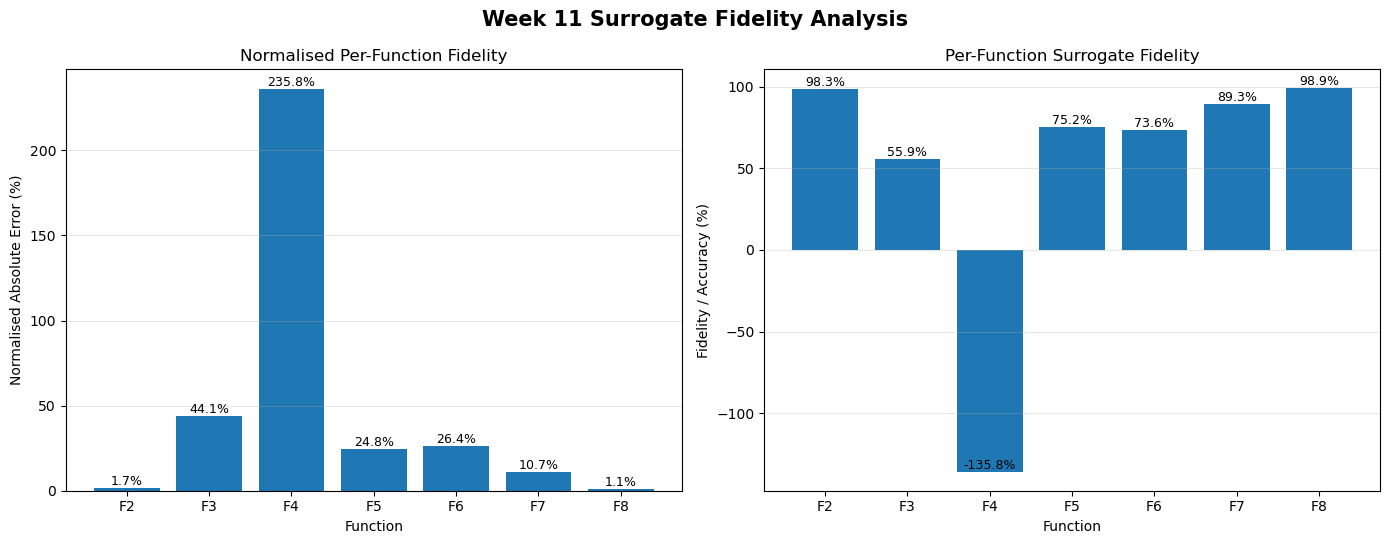

In [75]:
# =============================================================================
# Side-by-Side Plots:
# 1. Normalised Absolute Error
# 2. Per-Function Fidelity / Accuracy
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Exclude Function 1 because its actual value is ~3e-13, making
# percentage-based normalisation numerically unstable.
plot_df = normalised_df.dropna(
    subset=["Normalised Absolute Error", "Accuracy (%)"]
).copy()

functions = plot_df["Function"].str.replace("Function ", "F")
normalised_error = plot_df["Normalised Absolute Error"].values * 100
accuracy = plot_df["Accuracy (%)"].values

# -------------------------------------------------------------------------
# Create side-by-side plots
# -------------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5.5)
)

# =========================================================================
# Plot 1: Normalised Absolute Error
# =========================================================================

bars1 = axes[0].bar(
    functions,
    normalised_error
)

for bar, value in zip(bars1, normalised_error):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

axes[0].set_xlabel("Function")
axes[0].set_ylabel("Normalised Absolute Error (%)")
axes[0].set_title("Normalised Per-Function Fidelity")
axes[0].grid(
    axis="y",
    alpha=0.3
)

# =========================================================================
# Plot 2: Fidelity / Accuracy
# =========================================================================

bars2 = axes[1].bar(
    functions,
    accuracy
)

for bar, value in zip(bars2, accuracy):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

axes[1].set_xlabel("Function")
axes[1].set_ylabel("Fidelity / Accuracy (%)")
axes[1].set_title("Per-Function Surrogate Fidelity")
axes[1].grid(
    axis="y",
    alpha=0.3
)

# -------------------------------------------------------------------------
# Overall figure formatting
# -------------------------------------------------------------------------

fig.suptitle(
    "Week 11 Surrogate Fidelity Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()